# Machine Learning Part 3
In this code, the data will be preprocessed and examined for later Machine Learning purposes.

In [3]:
""
"  This Code is created by Daan Schat - 5169801 - TU Delft Master Student SET"
"  for the Green Village energy hub project"
""

# Setting up the environment:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg # Used later to export to PNG)
import random
import pandas as pd
import numpy as np
import os
import chardet
import seaborn as sn
from sklearn import svm
from sklearn.model_selection import GridSearchCV

from sklearn.svm import SVR


from sklearn.metrics import auc
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, roc_curve, precision_recall_curve, PrecisionRecallDisplay, roc_auc_score, RocCurveDisplay, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import explained_variance_score
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBClassifier
from xgboost import XGBRegressor

from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA

# Some variables & constants:
subfolder = "All dataframes/dataframes-full-set"
LHV_H2 = 120000000 # J/kg
HHV_H2 = 142000000 # J/kg
MolarVolume = 22.414 # L/mol.
MolarMass = 2.016 # g/mol
H2Density = MolarMass/MolarVolume # g/L
pickle_files = [os.path.splitext(f)[0] for f in os.listdir(subfolder) if f.endswith('.pkl')]
DataframesToLoad =  pickle_files # ["Battery_Current", "PV_Inverter_Active_Power","Battery_State_Of_Charge", "Electrolyser_Hydrogen_Flow_Rate"] # Please put the names of the dataframes (features) to load here


for var_name in DataframesToLoad:
    globals()[var_name] = pd.read_pickle(os.path.join(subfolder, f"{var_name}.pkl"))
    print(f"Loaded {var_name} from {subfolder}")



Loaded Temperature_Control_Outgoing_H2_Pipe_Heat_Tracing_Controller_Control_Signal from All dataframes/dataframes-full-set
Loaded Battery_Current from All dataframes/dataframes-full-set
Loaded Compressor_Stack_Coolant_Temperature_Out from All dataframes/dataframes-full-set
Loaded Pressure_Transmitter_Maximum_Pressure from All dataframes/dataframes-full-set
Loaded Outdoor_Convector_Outdoor_Convector_Flow from All dataframes/dataframes-full-set
Loaded Outdoor_Convector_Outdoor_Convector_Feed_Temperature from All dataframes/dataframes-full-set
Loaded Compressor_Compressor_Coolant_Temperature_In from All dataframes/dataframes-full-set
Loaded Compressor_PLC_Warning_Register from All dataframes/dataframes-full-set
Loaded Outdoor_Convector_Outdoor_Convector_Pump_Control_Signal from All dataframes/dataframes-full-set
Loaded Compressor_PLC_Yield_Output from All dataframes/dataframes-full-set
Loaded Temperature_Monitoring_Hydrogen_Cabinet_Temperature from All dataframes/dataframes-full-set
Loade

### Classification Classifier
We introduce a classifier function that takes all information (model, train/test sets, and name) and gives us the performance metrics accuracy, f1 score, precision, recall, ROC & AUC, and the confusion matrix)

In [5]:

def Classifier(clf,x_train,y_train,x_test,y_test, name):
    # Define the subfolder name
    figsubfolder = "figures/1-week/classification"
    if not os.path.exists(figsubfolder):
        os.makedirs(figsubfolder)
        
    #fit the model
    clf.fit(x_train, y_train)

    # Make predictions on the test set
    y_pred = clf.predict(x_test)

    # print the scores
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')
    recall    = recall_score(y_test, y_pred, average='macro')
    F1score   = f1_score(y_test, y_pred, average='macro')
    print(f"For the {name} model")
    print("Accuracy: " + str(accuracy))
    print("Precision score: " + str(precision))
    print("Recall score: " + str(recall))
    print("F1 score: " + str(F1score))

    num_classes = len(set(y_test))  # Number of unique classes in y_test
    class_labels = list(range(num_classes))  # Generate labels as 0,1,2,...,num_classes-1
    # plot the confusion matrix
    plt.figure(figsize=(5,5))
    confusion = confusion_matrix(y_test, y_pred)
    displayconfusion = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=class_labels) #display_labels=['0','1','2','3'])
    displayconfusion.plot()
    plt.title(f'Confusion Matrix - {name}')
    plt.savefig(os.path.join(figsubfolder, f"Confusion Matrix - {name}.png"), dpi=300, bbox_inches='tight')

    plt.show()


    if len(np.unique(y_test)) == 2:
      # ROC & AUC:
      lw = 2
      ax = plt.gca()
      y_score = clf.predict_proba(x_test)[:, 1]  # Use predict_proba for probabilities
      fpr_test, tpr_test, _ = roc_curve(y_test, y_score)
      auc_test = roc_auc_score(y_test, y_score)

      y_train_score = clf.predict_proba(x_train)[:, 1]
      fpr_train, tpr_train, _ = roc_curve(y_train, y_train_score)
      auc_train = roc_auc_score(y_train, y_train_score)

      # ROC curve for C=0.0001
      plt.plot(fpr_test, tpr_test, lw=lw, label=f'Test ROC curve (area = {auc_test:.2f})')
      plt.plot(fpr_train, tpr_train , lw=lw, label=f'Train ROC curve (area = {auc_train:.2f})', linestyle='--')
      plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
      plt.xlim([0.0, 1.0])
      plt.ylim([0.0, 1.05])
      plt.xlabel('False Positive Rate')
      plt.ylabel('True Positive Rate')
      plt.title(f"ROC Curve for {name}")
      plt.legend(loc='lower right')
      plt.savefig(os.path.join(figsubfolder, f"ROC - {name}.png"), dpi=300, bbox_inches='tight')
      plt.show()



### Hydrogen production classification
We are starting by predicting wether hydrogen is being produced or not (System state)

Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1-Score: 1.00


/var/folders/94/x7pykd1529z75np_t1jtxpzh0000gn/T/ipykernel_55180/2849470529.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined_df['H2_Produced'] = (combined_df['Electrolyser_Hydrogen_Flow_Rate'] > 10).astype(int) # prepare target


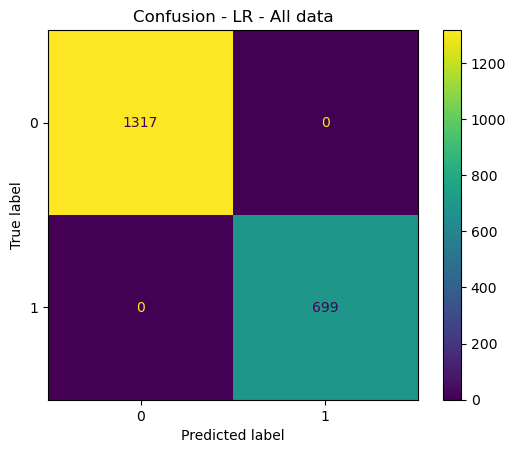

In [7]:
alldataframes = []
column_names = []

for var in DataframesToLoad:
    df = globals()[var]
    alldataframes.append(df[['value_float']])
    column_names.append(f'{var}')  # Create a custom column name


# Concatenate all DataFrames and save the names
combined_df = pd.concat(alldataframes, axis=1)
combined_df.columns = column_names

correlation_matrix = combined_df.corr()
np.fill_diagonal(correlation_matrix.values, 0)

# threshold from which we think a feature is worth saving
threshold = 0.9

# Looking for features that are strongly (above threshold)
strongly_correlated_columns = []
for column in correlation_matrix.columns:
    if (correlation_matrix[column].abs() > threshold).any():
        strongly_correlated_columns.append(column)



# Define the target column (binary classification)
# Assuming Electrolyser_Hydrogen_Flow_Rate > 0 indicates hydrogen production
for var in DataframesToLoad:
    df = globals()[var]
    alldataframes.append(df[['value_float']])
    column_names.append(f'{var}')
    
# Combine all DataFrames into one
combined_df = pd.concat(alldataframes, axis=1)
combined_df.columns = column_names 

combined_df = combined_df.loc[:, ~combined_df.columns.duplicated()] # Remove duplicates (gave problems without)
combined_df.fillna(0, inplace=True) # Remove NaN and insert 0 (gave problems without)
combined_df['H2_Produced'] = (combined_df['Electrolyser_Hydrogen_Flow_Rate'] > 10).astype(int) # prepare target


# Separate features and target
X = combined_df.drop(columns=['H2_Produced','Electrolyser_Hydrogen_Flow_Rate'])  # All features except target(s)
y = combined_df['H2_Produced']  # Target (1 or 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)


# Performance:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# Display confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion - LR - All data")
plt.savefig("Confusion - LR - All data")
plt.show()


Lets dumb this down, we'll only use the PV interter and weather data, this makes the prediction less accurate, but we want to see if we can predict hydrogen production at all with only these parameters.

Accuracy: 0.78
Precision: 0.70
Recall: 0.65
F1-Score: 0.68


/var/folders/94/x7pykd1529z75np_t1jtxpzh0000gn/T/ipykernel_55180/429570034.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined_df['H2_Produced'] = (combined_df['Electrolyser_Hydrogen_Flow_Rate'] > 10).astype(int) # prepare target


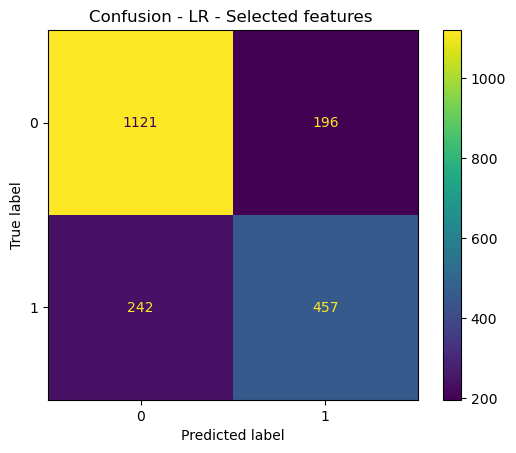

In [9]:
# Define the target column (binary classification)
# Assuming Electrolyser_Hydrogen_Flow_Rate > 0 indicates hydrogen production
# Importing pickle files:
pickle_files = [os.path.splitext(f)[0] for f in os.listdir(subfolder) if f.endswith('.pkl')]

# Load all pickle files available, or just the ones we need
DataframesToLoad =  pickle_files # ["Battery_Current", "PV_Inverter_Active_Power","Battery_State_Of_Charge", "Electrolyser_Hydrogen_Flow_Rate"] # Please put the names of the dataframes (features) to load here

for var in DataframesToLoad:
    globals()[var] = pd.read_pickle(os.path.join(subfolder, f"{var}.pkl"))

for var in DataframesToLoad:
    df = globals()[var]
    alldataframes.append(df[['value_float']])
    column_names.append(f'{var}')

# Combine all DataFrames into one
combined_df = pd.concat(alldataframes, axis=1)
combined_df.columns = column_names 


combined_df = combined_df.loc[:, ~combined_df.columns.duplicated()] # Remove duplicates (gave problems without)
combined_df.fillna(0, inplace=True) # Remove NaN and insert 0 (gave problems without)
combined_df['H2_Produced'] = (combined_df['Electrolyser_Hydrogen_Flow_Rate'] > 10).astype(int) # prepare target


# List of columns to drop (you can modify this list based on your requirements)
columns_to_drop = [
    "Battery_Current", "Battery_Power", "Battery_State_Of_Charge", "Battery_Temperature", 
    "Battery_Voltage", "Battery_Inverter_AC_In_Power", "Battery_Inverter_AC_Out_Power",
    "Battery_Inverter_Grid_Setpoint", "Compressor_Anode_Dewpoint", "Compressor_Anode_Heat_Tracing_Control_Signal",
    "Compressor_Anode_Heat_Tracing_Temperature", "Compressor_Anode_Pressure", "Compressor_Anode_Relative_Humidity",
    "Compressor_Anode_Temperature", "Compressor_Cathode_Pressure", "Compressor_Compressor_Coolant_Flow",
    "Compressor_Compressor_Coolant_Temperature_In", "Compressor_Compressor_Coolant_Temperature_Out",
    "Compressor_Compressor_Cooling_Notch_Ball_Valve_Control_Signal", "Compressor_Compressor_Cooling_Pump_Control_Signal",
    "Compressor_Current_State", "Compressor_Dryer_Pressure", "Compressor_Hydraulic_Pressure",
    "Compressor_Internal_Cooling_Heater_Control_Signal", "Compressor_PLC_Alarm_Register", "Compressor_PLC_Warning_Register",
    "Compressor_PLC_Yield_Output", "Compressor_PSU_Alarm_Register", "Compressor_PSU_Control_Register",
    "Compressor_PSU_Current_Energy_Consumption", "Compressor_PSU_Warning_Register", "Compressor_Power_On",
    "Compressor_Set_State", "Compressor_Stack_Coolant_Flow", "Compressor_Stack_Coolant_Pressure",
    "Compressor_Stack_Coolant_Temperature_In", "Compressor_Stack_Coolant_Temperature_Out",
    "Compressor_Stack_Cooling_Pump_Control_Signal", "Compressor_Energy_Meter_Active_Power",
    "Compressor_Energy_Meter_Apparent_Power", "Compressor_Energy_Meter_Current", "Compressor_Energy_Meter_Phase_Angle",
    "Compressor_Energy_Meter_Power_Factor", "Compressor_Energy_Meter_Reactive_Power", "Compressor_Energy_Meter_Voltage",
    "Drain_Drain_High_Level_Switch", "Electrolyser_Downstream_Temperature", "Electrolyser_Electrolyser_State",
    "Electrolyser_Electrolyte_Temperature", "Electrolyser_Inner_Hydrogen_Pressure", "Electrolyser_Outer_Hydrogen_Pressure",
    "Electrolyser_Power_On", "Electrolyser_Production_Rate", "Electrolyser_Stack_Current", "Electrolyser_Stack_Voltage",
    "Electrolyser_Start_Electrolyser", "Electrolyser_Start_Preheat", "Electrolyser_System_State", "Electrolyser_Water_Filling",
    "Electrolyser_Water_Inlet_Pressure", "Electrolyser_Energy_Meter_Active_Power", "Electrolyser_Energy_Meter_Apparent_Power",
    "Electrolyser_Energy_Meter_Current", "Electrolyser_Energy_Meter_Phase_Angle", "Electrolyser_Energy_Meter_Power_Factor",
    "Electrolyser_Energy_Meter_Reactive_Power", "Electrolyser_Energy_Meter_Voltage", "Heat_Buffer_Heat_Buffer_Bottom_Temperature",
    "Heat_Buffer_Heat_Buffer_Middle_Temperature", "Heat_Buffer_Heat_Buffer_Top_Temperature", "Indoor_Convector_Indoor_Convector_Feed_Temperature",
    "Indoor_Convector_Indoor_Convector_Flow", "Indoor_Convector_Indoor_Convector_Pump_Control_Signal",
    "Indoor_Convector_Indoor_Convector_Return_Temperature", "Mode_Selector_Mode_Selector_Battery", "Mode_Selector_Mode_Selector_Hydrogen",
    "Outdoor_Convector_Outdoor_Convector_Fan_Control_Signal", "Outdoor_Convector_Outdoor_Convector_Feed_Temperature",
    "Outdoor_Convector_Outdoor_Convector_Flow", "Outdoor_Convector_Outdoor_Convector_Pump_Control_Signal",
    "Outdoor_Convector_Outoor_Convector_Return_Temperature", "Pressure_Transmitter_Buffer_Status",
    "Pressure_Transmitter_Maximum_Pressure", "Pressure_Transmitter_Pressure", "Pressure_Transmitter_State_Of_Charge",
    "Temperature_Control_Compressor_Buffer_Cooling_Control_Signal", "Temperature_Control_Fuel_Cell_Buffer_Cooling_Control_Signal",
    "Temperature_Control_Indoor_Convector_Control_Signal", "Temperature_Control_Outgoing_H2_Pipe_Heat_Tracing_Controller_Control_Signal",
    "Temperature_Monitoring_Battery_Cabinet_Temperature", "Temperature_Monitoring_Container_Temperarture", 
    "Temperature_Monitoring_Hydrogen_Cabinet_Temperature",
    "Temperature_Monitoring_Outgoing_H2_Pipe_Temperature", "Ventilation_1_Emergency_Ventilation_1_Control_Signal",
    "Ventilation_1_Normal_Ventilation_1_Control_Signal", "Ventilation_1_Ventilation_1_Air_Speed", "Ventilation_2_Emergency_Ventilation_2_Control_Signal",
    "Ventilation_2_Normal_Ventilation_2_Control_Signal", "Ventilation_2_Ventilation_2_Air_Speed", "Water_Tank_Water_Feed_Tank_Low_Level_Switch"
]

# Drop the columns we don't need anymore
combined_df = combined_df.drop(columns=columns_to_drop, errors='ignore')


# Clean up the dataframe by removing NaN values (replace NaNs with 0 if needed)
combined_df.fillna(0, inplace=True)

# Create the target column (1 for hydrogen production, 0 otherwise)
combined_df['H2_Produced'] = (combined_df['Electrolyser_Hydrogen_Flow_Rate'] > 1).astype(int) # 1 if hydrogen production is above 10 NL/h

# Separate features and target
X = combined_df.drop(columns=['H2_Produced', 'Electrolyser_Hydrogen_Flow_Rate'])  # All features except target(s)
y = combined_df['H2_Produced']  # Target (1 or 0)

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a logistic regression model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

# Performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# Display confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion - LR - Selected features ")
plt.savefig("Confusion - LR - Selected features")
plt.show()



We can clearly see that some features are more important than others and so we can look up those features by PCA.

Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1-Score: 1.00
Explained variance ratio: [0.60352393 0.07527395 0.06731138 0.04447282 0.02672468 0.02577398
 0.02088683 0.01982934 0.01559744 0.01465224]


/var/folders/94/x7pykd1529z75np_t1jtxpzh0000gn/T/ipykernel_2627/3620138868.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined_df['H2_Produced'] = (combined_df['Electrolyser_Hydrogen_Flow_Rate'] > 10).astype(int) # prepare target


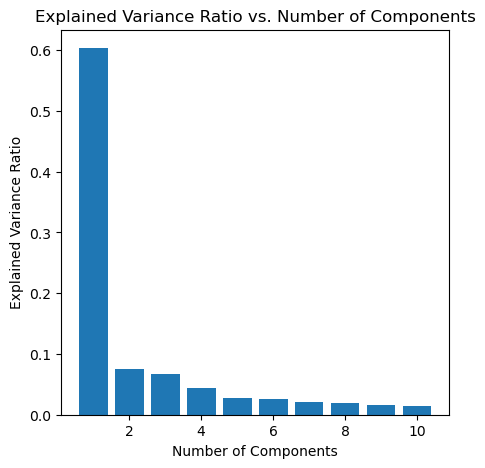

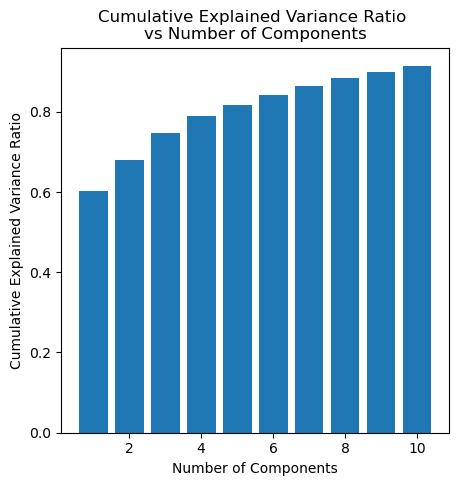

In [75]:
# Define the target column (binary classification)
# Assuming Electrolyser_Hydrogen_Flow_Rate > 0 indicates hydrogen production
for var in DataframesToLoad:
    df = globals()[var]
    alldataframes.append(df[['value_float']])
    column_names.append(f'{var}')
    
# Combine all DataFrames into one
combined_df = pd.concat(alldataframes, axis=1)
combined_df.columns = column_names 

combined_df = combined_df.loc[:, ~combined_df.columns.duplicated()] # Remove duplicates (gave problems without)
combined_df.fillna(0, inplace=True) # Remove NaN and insert 0 (gave problems without)
combined_df['H2_Produced'] = (combined_df['Electrolyser_Hydrogen_Flow_Rate'] > 10).astype(int) # prepare target


# Separate features and target
X = combined_df.drop(columns=['H2_Produced','Electrolyser_Hydrogen_Flow_Rate'])  # All features except target(s)
y = combined_df['H2_Produced']  # Target (1 or 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)


# Performance:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# Choose the number of principal components you want to keep
n_components = 10  # You can adjust this based on explained variance ratio

# Create a PCA object
pca = PCA(n_components=n_components)

# Fit and transform the training data
x_train_pca = pca.fit_transform(X_train_scaled)
x_test_pca = pca.transform(X_test_scaled)

# Print the explained variance ratio
print("Explained variance ratio:", pca.explained_variance_ratio_)

# You can now use x_train_2c_pca and x_test_2c_pca for training and testing your model
# with the reduced dimensionality data.


plt.figure(figsize=(5,5))

plt.bar(range(1, n_components+1), pca.explained_variance_ratio_)
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio vs. Number of Components')
plt.savefig("explained variance ratio")

plt.show()

plt.figure(figsize=(5,5))
cumul_expl_var_ratio=np.cumsum(pca.explained_variance_ratio_[0:20])
plt.bar(range(1, n_components+1), cumul_expl_var_ratio)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.title("Cumulative Explained Variance Ratio \nvs Number of Components")
plt.savefig("explained variance cumulative")
plt.show()

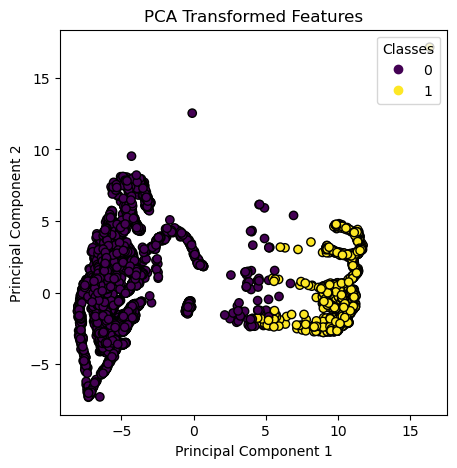

In [77]:

pca = PCA()
x_pca = pca.fit_transform(X_train_scaled)

# Plot the first two principal components of each point

plt.figure(figsize=(5,5))
# plt.scatter(x_pca[:, 0], x_pca[:, 1], c=labels)
scatter = plt.scatter(x_pca[:, 0], x_pca[:, 1], c=y_train, cmap='viridis', edgecolor='k')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Transformed Features')
legend = plt.legend(*scatter.legend_elements(), title="Classes", loc="upper right")
plt.savefig("PCA - 2 class")
plt.show()

### Multiple model testing
Here we test different types of classification models to test the  best ones for this purpose. As seen before, when using all of the available data, we get an accuracy of 100%, so to better distinguish results, the slimmed down dataset is used here.

   Temperature_Monitoring_Outdoor_Temperature  \
0                                   17.400000   
1                                   17.366667   
2                                   17.116667   
3                                   17.025000   
4                                   16.966667   

   Electrolyser_Hydrogen_Flow_Rate  PV_Inverter_Active_Power  
0                              0.0                       0.0  
1                              0.0                       0.0  
2                              0.0                       0.0  
3                              0.0                       0.0  
4                              0.0                       0.0  
For the Logistic Regression model
Accuracy: 0.7738095238095238
Precision score: 0.765027835456036
Recall score: 0.7912996438126709
F1 score: 0.7657474556490451


<Figure size 500x500 with 0 Axes>

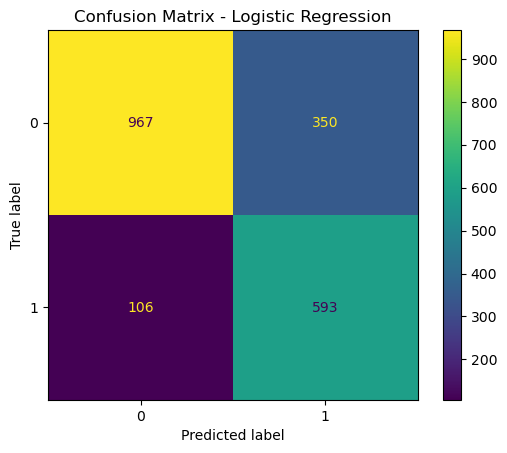

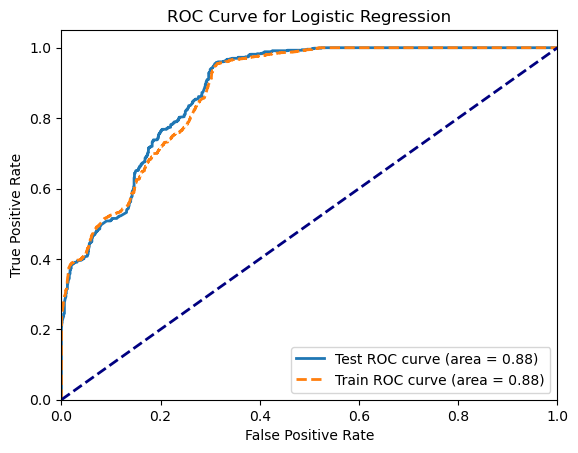

Training k-NN with n_neighbors=1
For the KNN - 1 model
Accuracy: 0.8511904761904762
Precision score: 0.8356427265774586
Recall score: 0.8360919113214126
F1 score: 0.8358662613981762


<Figure size 500x500 with 0 Axes>

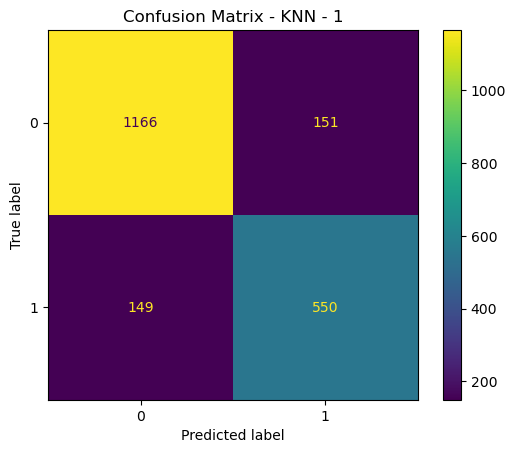

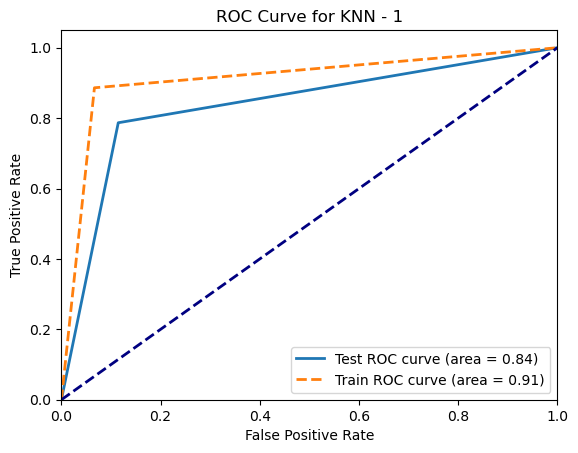

Training k-NN with n_neighbors=2
For the KNN - 2 model
Accuracy: 0.8561507936507936
Precision score: 0.8583197133632993
Recall score: 0.8184063794356402
F1 score: 0.8327564406963904


<Figure size 500x500 with 0 Axes>

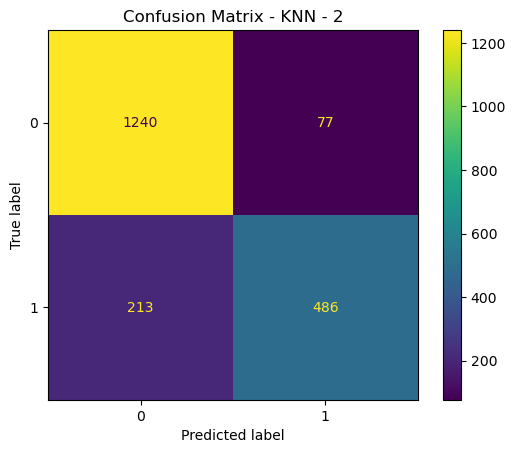

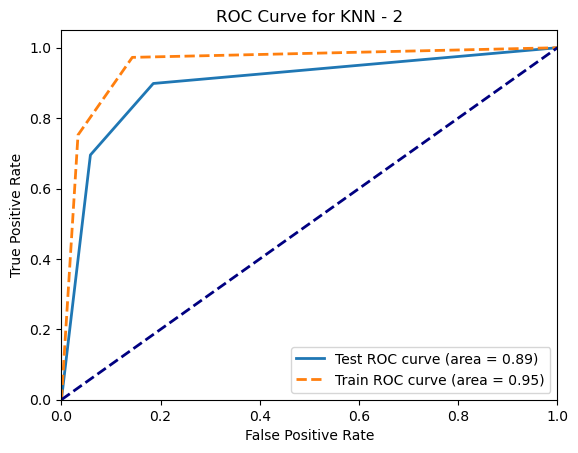

Training k-NN with n_neighbors=3
For the KNN - 3 model
Accuracy: 0.8616071428571429
Precision score: 0.8453974184782609
Recall score: 0.8534629685753485
F1 score: 0.8490716304929703


<Figure size 500x500 with 0 Axes>

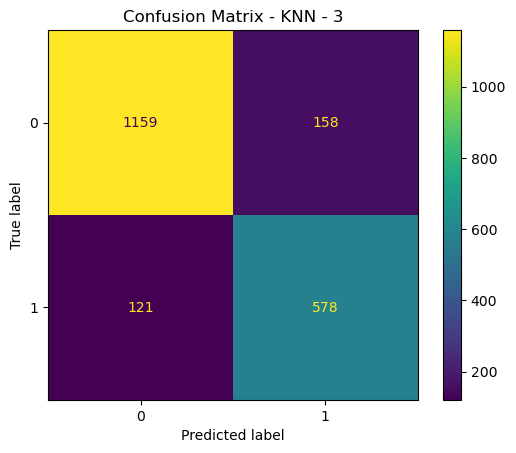

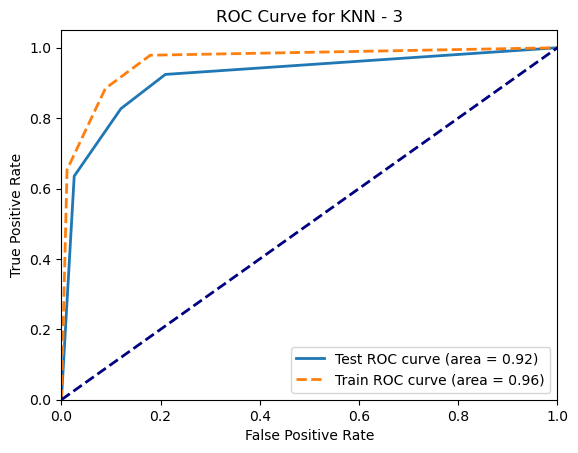

Training k-NN with n_neighbors=4
For the KNN - 4 model
Accuracy: 0.8665674603174603
Precision score: 0.8628887559808612
Recall score: 0.8374557209941961
F1 score: 0.8477347802587338


<Figure size 500x500 with 0 Axes>

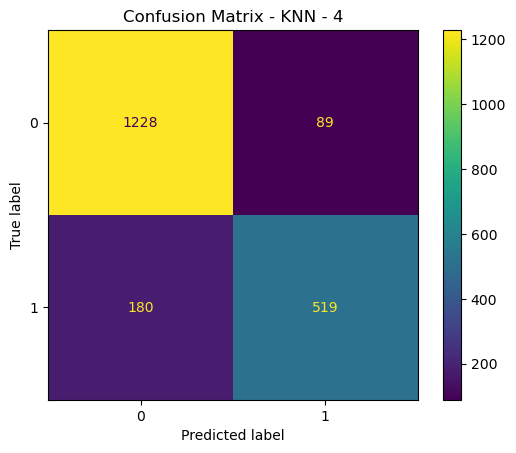

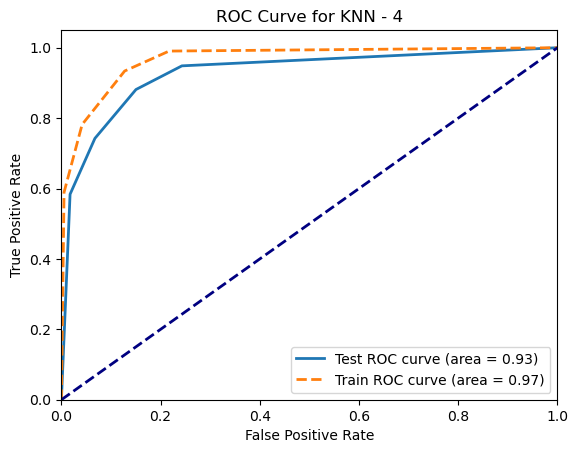

Training k-NN with n_neighbors=7
For the KNN - 7 model
Accuracy: 0.873015873015873
Precision score: 0.858776734410862
Recall score: 0.862530592027009
F1 score: 0.8605843777655076


<Figure size 500x500 with 0 Axes>

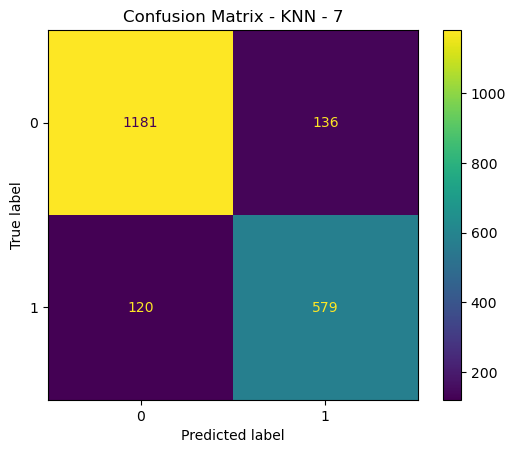

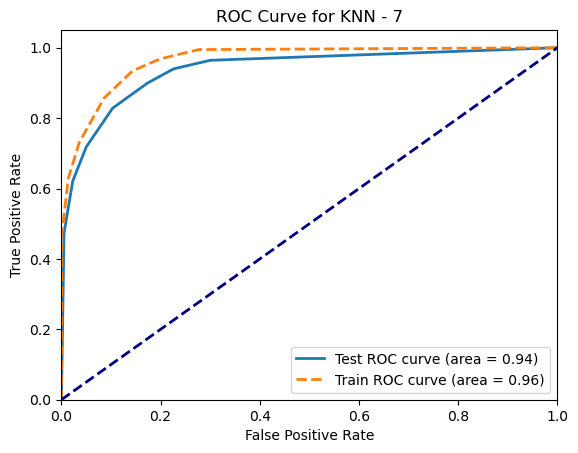

Training SVC with kernel=linear
For the svm linear model
Accuracy: 0.7619047619047619
Precision score: 0.7387949464362067
Recall score: 0.7214341346733537
F1 score: 0.727974380655956


<Figure size 500x500 with 0 Axes>

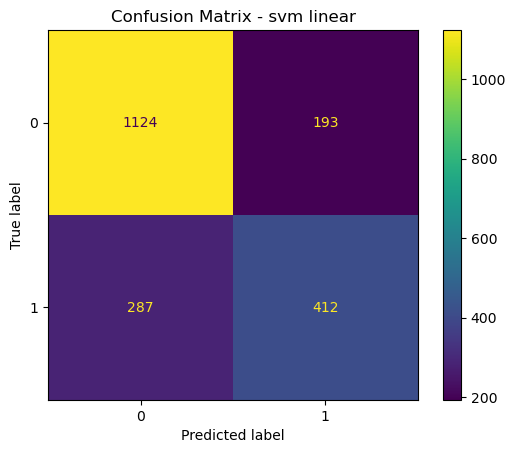

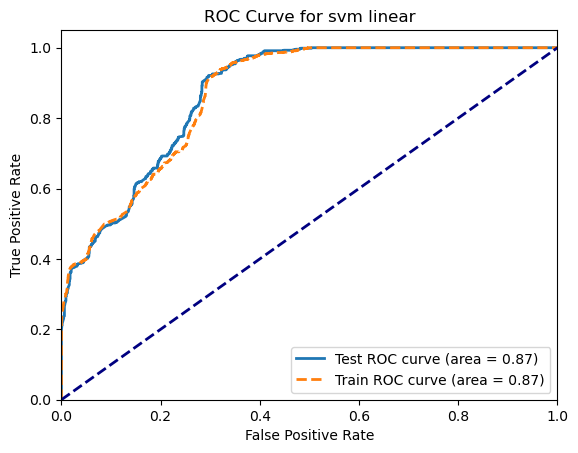

Training SVC with kernel=rbf
For the svm rbf model
Accuracy: 0.8690476190476191
Precision score: 0.8656716417910448
Recall score: 0.8403609451836499
F1 score: 0.8506244190276038


<Figure size 500x500 with 0 Axes>

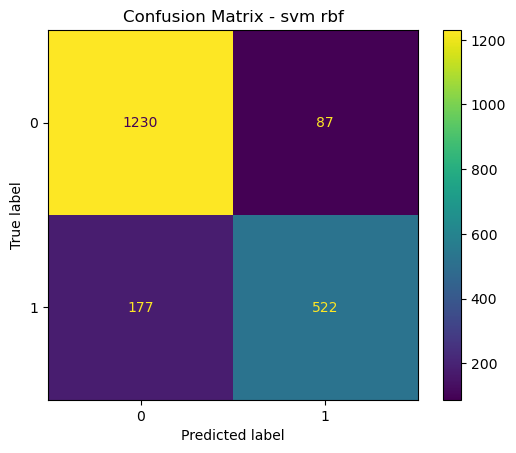

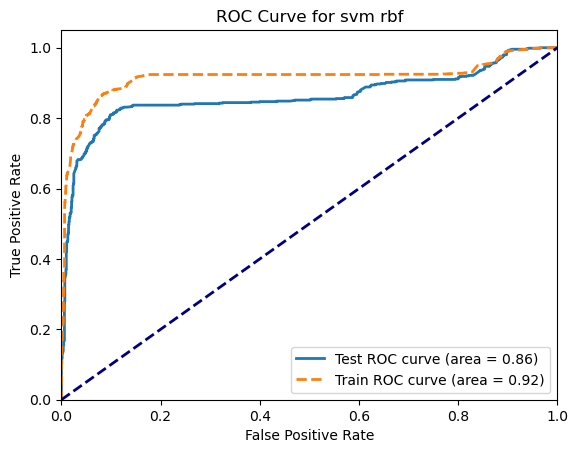

For the Decision Tree model
Accuracy: 0.8948412698412699
Precision score: 0.8863733532189908
Recall score: 0.8799065374876573
F1 score: 0.882973375259988


<Figure size 500x500 with 0 Axes>

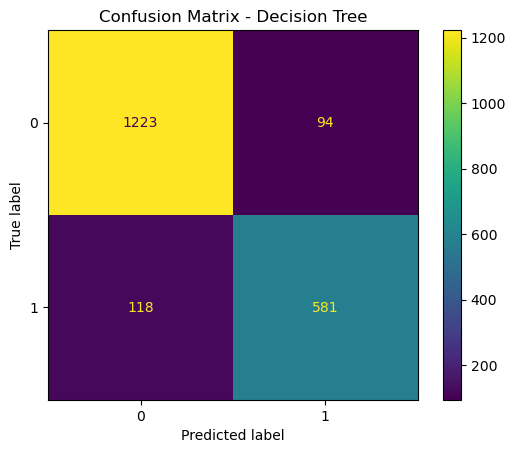

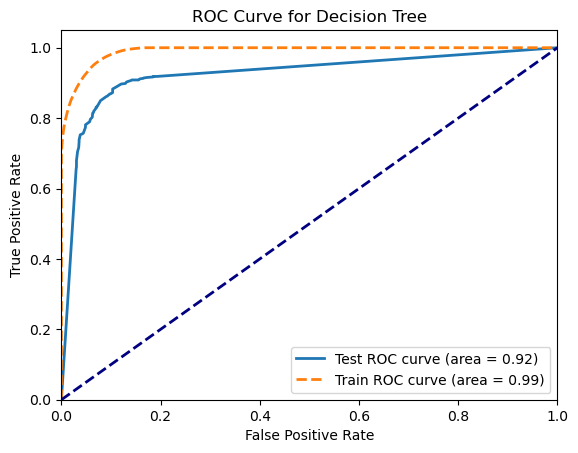

For the Random Forest model
Accuracy: 0.8913690476190477
Precision score: 0.8776063031622083
Recall score: 0.8859760608223267
F1 score: 0.8814552915972029


<Figure size 500x500 with 0 Axes>

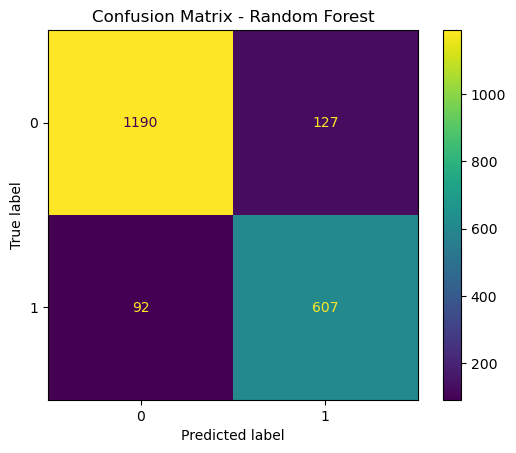

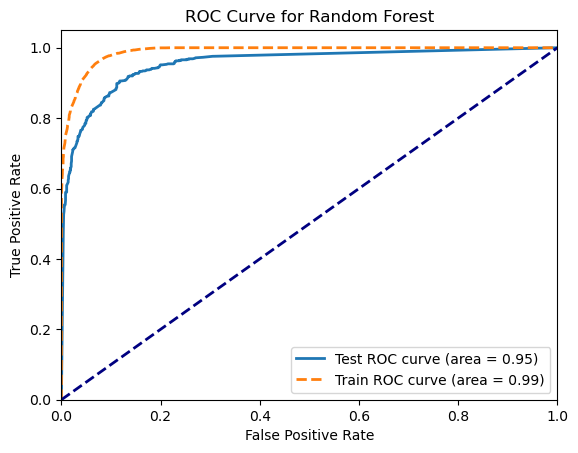

/opt/anaconda3/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [11:36:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


For the XGBoost model
Accuracy: 0.9012896825396826
Precision score: 0.8960634863701578
Recall score: 0.8838350262822581
F1 score: 0.8893997935123169


<Figure size 500x500 with 0 Axes>

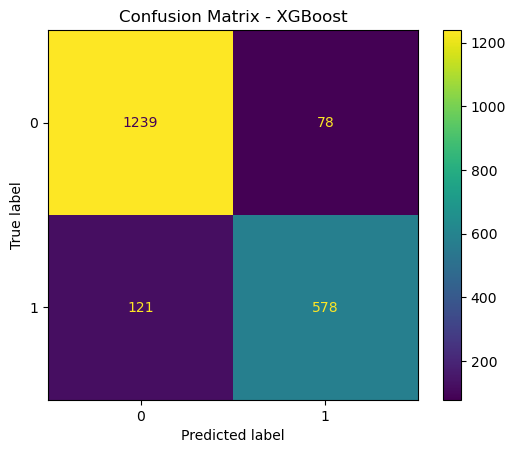

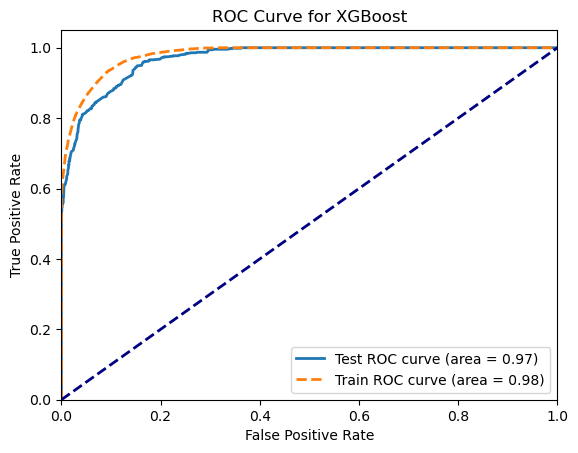

For the Naive Bayes model
Accuracy: 0.7415674603174603
Precision score: 0.770838704479536
Recall score: 0.7921322683560309
F1 score: 0.7399905485855431


<Figure size 500x500 with 0 Axes>

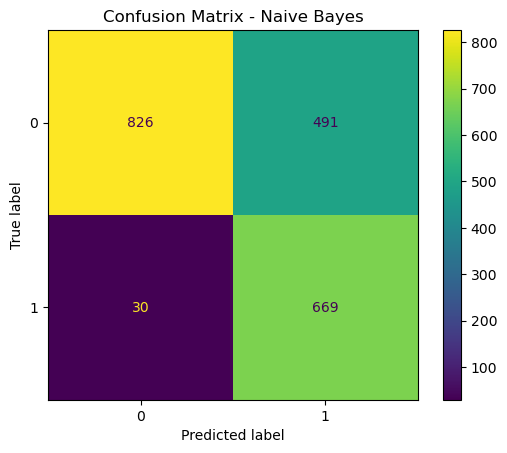

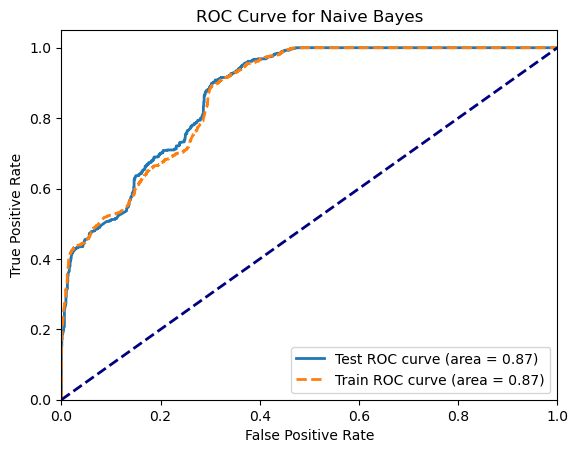

For the Neural Network - 100 model
Accuracy: 0.8115079365079365
Precision score: 0.7917021137360121
Recall score: 0.805048539892655
F1 score: 0.7969388144585672


<Figure size 500x500 with 0 Axes>

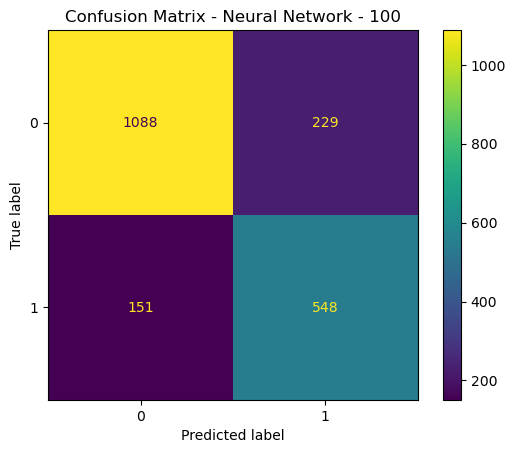

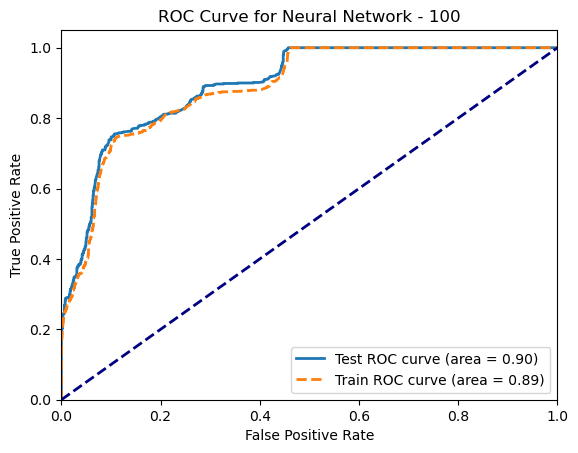

For the Neural Network - (100, 100) model
Accuracy: 0.839781746031746
Precision score: 0.8378099173553719
Recall score: 0.800507395856756
F1 score: 0.8138055447613508


<Figure size 500x500 with 0 Axes>

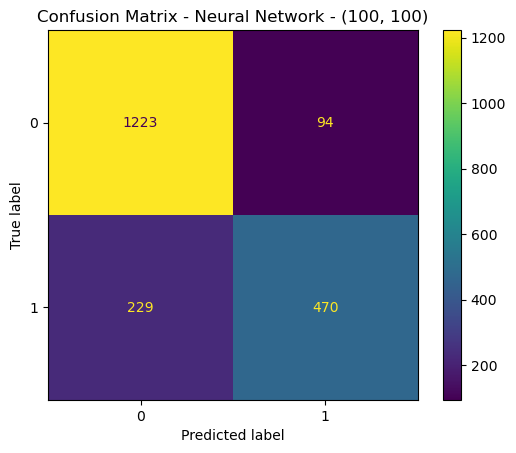

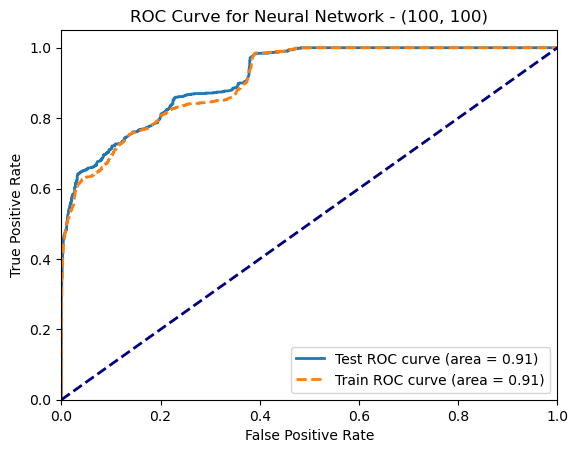

For the Neural Network - (100, 100, 100) model
Accuracy: 0.8442460317460317
Precision score: 0.8301812770412422
Recall score: 0.8227210365605274
F1 score: 0.8261761633673426


<Figure size 500x500 with 0 Axes>

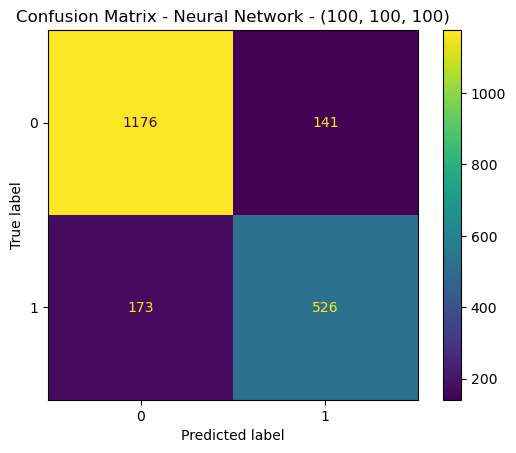

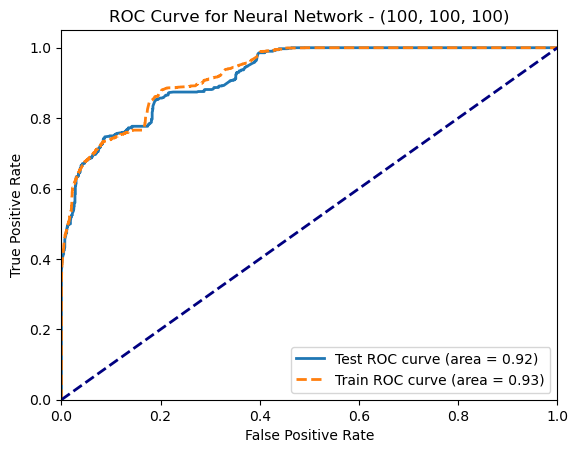

In [79]:
# Define the target column (binary classification)
# Assuming Electrolyser_Hydrogen_Flow_Rate > 1 indicates hydrogen production
# Importing pickle files:
pickle_files = [os.path.splitext(f)[0] for f in os.listdir(subfolder) if f.endswith('.pkl')]
 
# Load all pickle files available, or just the ones we need
DataframesToLoad =  pickle_files # ["Battery_Current", "PV_Inverter_Active_Power","Battery_State_Of_Charge", "Electrolyser_Hydrogen_Flow_Rate"] # Please put the names of the dataframes (features) to load here

for var in DataframesToLoad:
    globals()[var] = pd.read_pickle(os.path.join(subfolder, f"{var}.pkl"))

for var in DataframesToLoad:
    df = globals()[var]
    alldataframes.append(df[['value_float']])
    column_names.append(f'{var}')

# Combine all DataFrames into one
combined_df = pd.concat(alldataframes, axis=1)
combined_df.columns = column_names 

combined_df = combined_df.loc[:, ~combined_df.columns.duplicated()] # Remove duplicates (gave problems without)
combined_df.fillna(0, inplace=True) # Remove NaN and insert 0 (gave problems without)


# List of columns to drop (you can modify this list based on your requirements)
columns_to_drop = [
    "Battery_Current", "Battery_Power", "Battery_State_Of_Charge", "Battery_Temperature", 
    "Battery_Voltage", "Battery_Inverter_AC_In_Power", "Battery_Inverter_AC_Out_Power",
    "Battery_Inverter_Grid_Setpoint", "Compressor_Anode_Dewpoint", "Compressor_Anode_Heat_Tracing_Control_Signal",
    "Compressor_Anode_Heat_Tracing_Temperature", "Compressor_Anode_Pressure", "Compressor_Anode_Relative_Humidity",
    "Compressor_Anode_Temperature", "Compressor_Cathode_Pressure", "Compressor_Compressor_Coolant_Flow",
    "Compressor_Compressor_Coolant_Temperature_In", "Compressor_Compressor_Coolant_Temperature_Out",
    "Compressor_Compressor_Cooling_Notch_Ball_Valve_Control_Signal", "Compressor_Compressor_Cooling_Pump_Control_Signal",
    "Compressor_Current_State", "Compressor_Dryer_Pressure", "Compressor_Hydraulic_Pressure",
    "Compressor_Internal_Cooling_Heater_Control_Signal", "Compressor_PLC_Alarm_Register", "Compressor_PLC_Warning_Register",
    "Compressor_PLC_Yield_Output", "Compressor_PSU_Alarm_Register", "Compressor_PSU_Control_Register",
    "Compressor_PSU_Current_Energy_Consumption", "Compressor_PSU_Warning_Register", "Compressor_Power_On",
    "Compressor_Set_State", "Compressor_Stack_Coolant_Flow", "Compressor_Stack_Coolant_Pressure",
    "Compressor_Stack_Coolant_Temperature_In", "Compressor_Stack_Coolant_Temperature_Out",
    "Compressor_Stack_Cooling_Pump_Control_Signal", "Compressor_Energy_Meter_Active_Power",
    "Compressor_Energy_Meter_Apparent_Power", "Compressor_Energy_Meter_Current", "Compressor_Energy_Meter_Phase_Angle",
    "Compressor_Energy_Meter_Power_Factor", "Compressor_Energy_Meter_Reactive_Power", "Compressor_Energy_Meter_Voltage",
    "Drain_Drain_High_Level_Switch", "Electrolyser_Downstream_Temperature", "Electrolyser_Electrolyser_State",
    "Electrolyser_Electrolyte_Temperature", "Electrolyser_Inner_Hydrogen_Pressure", "Electrolyser_Outer_Hydrogen_Pressure",
    "Electrolyser_Power_On", "Electrolyser_Production_Rate", "Electrolyser_Stack_Current", "Electrolyser_Stack_Voltage",
    "Electrolyser_Start_Electrolyser", "Electrolyser_Start_Preheat", "Electrolyser_System_State", "Electrolyser_Water_Filling",
    "Electrolyser_Water_Inlet_Pressure", "Electrolyser_Energy_Meter_Active_Power", "Electrolyser_Energy_Meter_Apparent_Power",
    "Electrolyser_Energy_Meter_Current", "Electrolyser_Energy_Meter_Phase_Angle", "Electrolyser_Energy_Meter_Power_Factor",
    "Electrolyser_Energy_Meter_Reactive_Power", "Electrolyser_Energy_Meter_Voltage", "Heat_Buffer_Heat_Buffer_Bottom_Temperature",
    "Heat_Buffer_Heat_Buffer_Middle_Temperature", "Heat_Buffer_Heat_Buffer_Top_Temperature", "Indoor_Convector_Indoor_Convector_Feed_Temperature",
    "Indoor_Convector_Indoor_Convector_Flow", "Indoor_Convector_Indoor_Convector_Pump_Control_Signal",
    "Indoor_Convector_Indoor_Convector_Return_Temperature", "Mode_Selector_Mode_Selector_Battery", "Mode_Selector_Mode_Selector_Hydrogen",
    "Outdoor_Convector_Outdoor_Convector_Fan_Control_Signal", "Outdoor_Convector_Outdoor_Convector_Feed_Temperature",
    "Outdoor_Convector_Outdoor_Convector_Flow", "Outdoor_Convector_Outdoor_Convector_Pump_Control_Signal",
    "Outdoor_Convector_Outoor_Convector_Return_Temperature", "Pressure_Transmitter_Buffer_Status",
    "Pressure_Transmitter_Maximum_Pressure", "Pressure_Transmitter_Pressure", "Pressure_Transmitter_State_Of_Charge",
    "Temperature_Control_Compressor_Buffer_Cooling_Control_Signal", "Temperature_Control_Fuel_Cell_Buffer_Cooling_Control_Signal",
    "Temperature_Control_Indoor_Convector_Control_Signal", "Temperature_Control_Outgoing_H2_Pipe_Heat_Tracing_Controller_Control_Signal",
    "Temperature_Monitoring_Battery_Cabinet_Temperature", "Temperature_Monitoring_Container_Temperarture", 
    "Temperature_Monitoring_Hydrogen_Cabinet_Temperature",
    "Temperature_Monitoring_Outgoing_H2_Pipe_Temperature", "Ventilation_1_Emergency_Ventilation_1_Control_Signal",
    "Ventilation_1_Normal_Ventilation_1_Control_Signal", "Ventilation_1_Ventilation_1_Air_Speed", "Ventilation_2_Emergency_Ventilation_2_Control_Signal",
    "Ventilation_2_Normal_Ventilation_2_Control_Signal", "Ventilation_2_Ventilation_2_Air_Speed", "Water_Tank_Water_Feed_Tank_Low_Level_Switch"
]

# Drop the specified columns
combined_df = combined_df.drop(columns=columns_to_drop, errors='ignore')

print(combined_df.head())

# Clean up the dataframe by removing NaN values (replace NaNs with 0 if needed)
combined_df.fillna(0, inplace=True)

# Create the binary target column (1 for hydrogen production, 0 otherwise)
combined_df = pd.concat([combined_df, 
                         (combined_df['Electrolyser_Hydrogen_Flow_Rate'] > 10).astype(int).rename('H2_Produced')], 
                         axis=1)


# Separate features and target
X = combined_df.drop(columns=['H2_Produced', 'Electrolyser_Hydrogen_Flow_Rate'])  # All features except target(s)
y = combined_df['H2_Produced']  # Target (1 or 0)

X_scaled = scaler.fit_transform(X)

# Split data into training and test sets
x_train_2c, x_test_2c, y_train_2c, y_test_2c = train_test_split(X, y, test_size=0.2, random_state=42)


#Logistic regression - does not work well enough
LRmodel =  LogisticRegression(class_weight='balanced')
Classifier(LRmodel,x_train_2c,y_train_2c,x_test_2c,y_test_2c, 'Logistic Regression')

# K-NN:
for n in [1,2,3,4,7]:
    print(f"Training k-NN with n_neighbors={n}")
    knn_clf = KNeighborsClassifier(n_neighbors=n)
    Classifier(knn_clf,x_train_2c,y_train_2c,x_test_2c,y_test_2c, f'KNN - {n}')

### SVM: - kernels=['linear','poly','rbf'], [gamma='auto', random_state=42, C=1.0, coef0=0.0, tol=1e-3]
kernels = ['linear', 'rbf'] # poly gave long runtimes
for kernel in kernels:
    print(f"Training SVC with kernel={kernel}")
    if kernel == 'poly':
        svm_clf = SVC(kernel=kernel, degree=3, gamma='auto', random_state=42, C=1.0, coef0=0.0, tol=1e-3, probability=True)
    else:
        svm_clf = SVC(kernel=kernel, gamma='auto', random_state=42, C=1.0, coef0=0.0, tol=1e-3, probability=True)
    Classifier(svm_clf, x_train_2c, y_train_2c, x_test_2c, y_test_2c, f'svm {kernel}')

# Decision tree:
dt_clf = DecisionTreeClassifier(random_state=42)
Classifier(dt_clf, x_train_2c, y_train_2c, x_test_2c, y_test_2c, 'Decision Tree')

# Random forest:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
Classifier(rf_clf, x_train_2c, y_train_2c, x_test_2c, y_test_2c, 'Random Forest')

# Gradient boosting:
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
Classifier(xgb_clf, x_train_2c, y_train_2c, x_test_2c, y_test_2c, 'XGBoost')

# Naive bays:
nb_clf = GaussianNB()
Classifier(nb_clf, x_train_2c, y_train_2c, x_test_2c, y_test_2c, 'Naive Bayes')

for hidden_layers in [(100), (100,100), (100,100,100)]:
    mlp_clf = MLPClassifier(hidden_layers, max_iter=500, random_state=42)
    Classifier(mlp_clf, x_train_2c, y_train_2c, x_test_2c, y_test_2c, f'Neural Network - {hidden_layers}')

From the model evaluation above, we can conclude that the KNN 3 works best for the more simple models and Gradient Boost model for the more advanced models, so we can tune these models further.

Training k-NN with n_neighbors=7
For the KNN - 7 model
Accuracy: 0.873015873015873
Precision score: 0.858776734410862
Recall score: 0.862530592027009
F1 score: 0.8605843777655076


<Figure size 500x500 with 0 Axes>

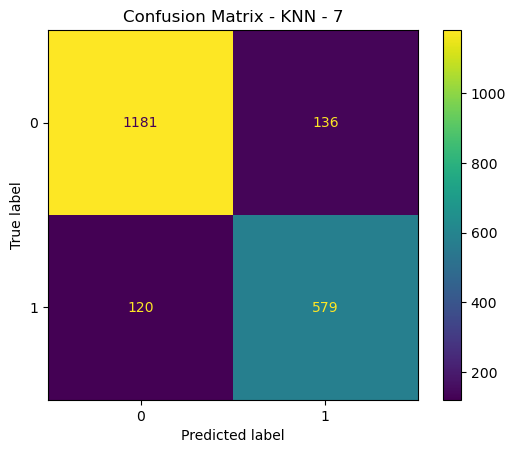

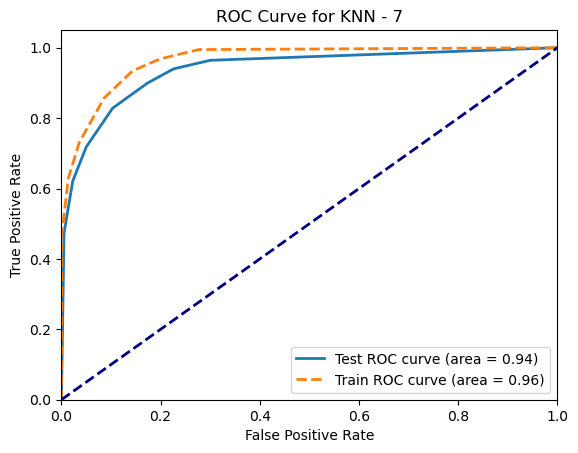

For the XGBoost model
Accuracy: 0.9012896825396826
Precision score: 0.8960634863701578
Recall score: 0.8838350262822581
F1 score: 0.8893997935123169


<Figure size 500x500 with 0 Axes>

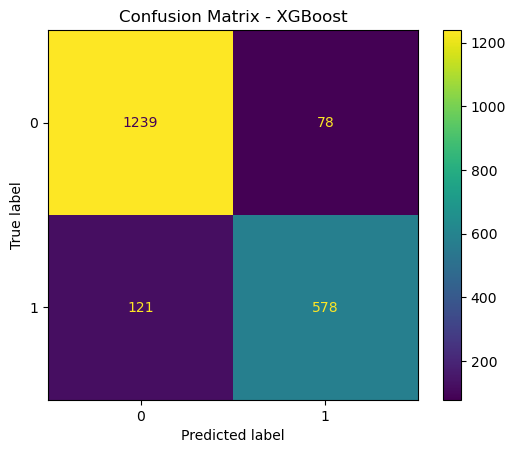

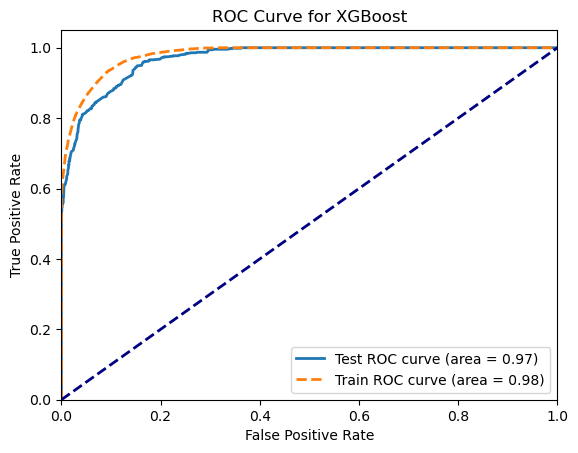

For the Decision Tree model
Accuracy: 0.8948412698412699
Precision score: 0.8863733532189908
Recall score: 0.8799065374876573
F1 score: 0.882973375259988


<Figure size 500x500 with 0 Axes>

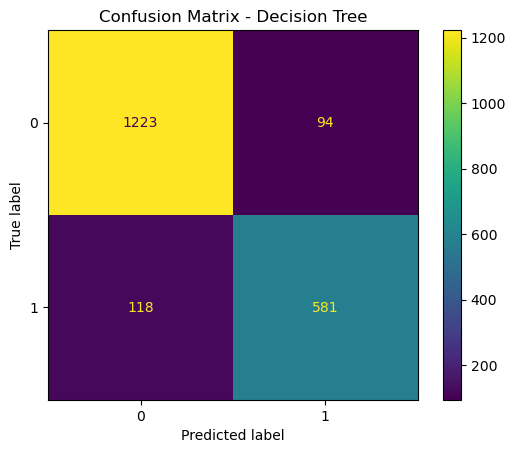

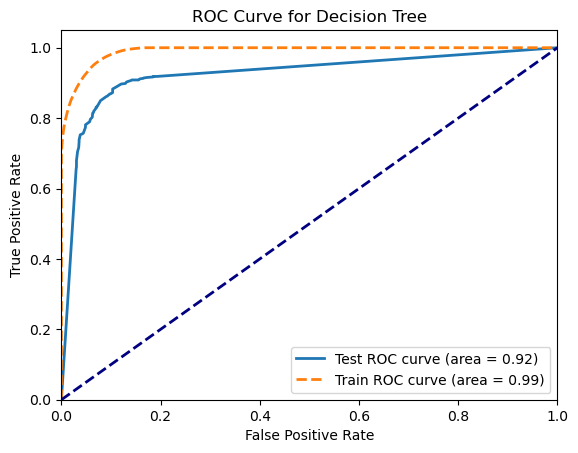

In [84]:
from sklearn.metrics import classification_report
for n in [7]:
    print(f"Training k-NN with n_neighbors={n}")
    knn_clf = KNeighborsClassifier(n_neighbors=n)
    Classifier(knn_clf,x_train_2c,y_train_2c,x_test_2c,y_test_2c, f'KNN - {n}')

# Gradient boosting:
xgb_clf = XGBClassifier(eval_metric='logloss', random_state=42)
Classifier(xgb_clf, x_train_2c, y_train_2c, x_test_2c, y_test_2c, 'XGBoost')


dt_clf = DecisionTreeClassifier(random_state=42)
Classifier(dt_clf, x_train_2c, y_train_2c, x_test_2c, y_test_2c, 'Decision Tree')


In [86]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]
}

grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid_search.fit(x_train_2c, y_train_2c)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best score: {grid_search.best_score_}")

Best parameters: {'metric': 'manhattan', 'n_neighbors': 5, 'p': 1, 'weights': 'distance'}
Best score: 0.8796991411284554


# Machine learning part 2
This part of the machine learning will cover an estimation on hydrogen production based on temperature and PV power.

In [87]:
alldataframes = []
column_names = []

# We set up the features and target:
for var in DataframesToLoad:
    df = globals()[var]
    alldataframes.append(df[['value_float']])
    column_names.append(f'{var}')
    
# Combine all DataFrames into one
combined_df = pd.concat(alldataframes, axis=1)
combined_df.columns = column_names
combined_df['time'] = globals()[DataframesToLoad[0]]['time']

combined_df = combined_df.loc[:, ~combined_df.columns.duplicated()] # Remove duplicates (gave problems without)
combined_df.fillna(0, inplace=True) # Remove NaN and insert 0 (gave problems without)
combined_df['H2_Produced'] = combined_df['Electrolyser_Hydrogen_Flow_Rate'] # prepare target

# List of columns to drop (you can modify this list based on your requirements)
columns_to_drop = [
    "Battery_Current", "Battery_Power", "Battery_State_Of_Charge", "Battery_Temperature", 
    "Battery_Voltage", "Battery_Inverter_AC_In_Power", "Battery_Inverter_AC_Out_Power",
    "Battery_Inverter_Grid_Setpoint", "Compressor_Anode_Dewpoint", "Compressor_Anode_Heat_Tracing_Control_Signal",
    "Compressor_Anode_Heat_Tracing_Temperature", "Compressor_Anode_Pressure", "Compressor_Anode_Relative_Humidity",
    "Compressor_Anode_Temperature", "Compressor_Cathode_Pressure", "Compressor_Compressor_Coolant_Flow",
    "Compressor_Compressor_Coolant_Temperature_In", "Compressor_Compressor_Coolant_Temperature_Out",
    "Compressor_Compressor_Cooling_Notch_Ball_Valve_Control_Signal", "Compressor_Compressor_Cooling_Pump_Control_Signal",
    "Compressor_Current_State", "Compressor_Dryer_Pressure", "Compressor_Hydraulic_Pressure",
    "Compressor_Internal_Cooling_Heater_Control_Signal", "Compressor_PLC_Alarm_Register", "Compressor_PLC_Warning_Register",
    "Compressor_PLC_Yield_Output", "Compressor_PSU_Alarm_Register", "Compressor_PSU_Control_Register",
    "Compressor_PSU_Current_Energy_Consumption", "Compressor_PSU_Warning_Register", "Compressor_Power_On",
    "Compressor_Set_State", "Compressor_Stack_Coolant_Flow", "Compressor_Stack_Coolant_Pressure",
    "Compressor_Stack_Coolant_Temperature_In", "Compressor_Stack_Coolant_Temperature_Out",
    "Compressor_Stack_Cooling_Pump_Control_Signal", "Compressor_Energy_Meter_Active_Power",
    "Compressor_Energy_Meter_Apparent_Power", "Compressor_Energy_Meter_Current", "Compressor_Energy_Meter_Phase_Angle",
    "Compressor_Energy_Meter_Power_Factor", "Compressor_Energy_Meter_Reactive_Power", "Compressor_Energy_Meter_Voltage",
    "Drain_Drain_High_Level_Switch", "Electrolyser_Downstream_Temperature", "Electrolyser_Electrolyser_State",
    "Electrolyser_Electrolyte_Temperature", "Electrolyser_Inner_Hydrogen_Pressure", "Electrolyser_Outer_Hydrogen_Pressure",
    "Electrolyser_Power_On", "Electrolyser_Production_Rate", "Electrolyser_Stack_Current", "Electrolyser_Stack_Voltage",
    "Electrolyser_Start_Electrolyser", "Electrolyser_Start_Preheat", "Electrolyser_System_State", "Electrolyser_Water_Filling",
    "Electrolyser_Water_Inlet_Pressure", "Electrolyser_Energy_Meter_Active_Power", "Electrolyser_Energy_Meter_Apparent_Power",
    "Electrolyser_Energy_Meter_Current", "Electrolyser_Energy_Meter_Phase_Angle", "Electrolyser_Energy_Meter_Power_Factor",
    "Electrolyser_Energy_Meter_Reactive_Power", "Electrolyser_Energy_Meter_Voltage", "Heat_Buffer_Heat_Buffer_Bottom_Temperature",
    "Heat_Buffer_Heat_Buffer_Middle_Temperature", "Heat_Buffer_Heat_Buffer_Top_Temperature", "Indoor_Convector_Indoor_Convector_Feed_Temperature",
    "Indoor_Convector_Indoor_Convector_Flow", "Indoor_Convector_Indoor_Convector_Pump_Control_Signal",
    "Indoor_Convector_Indoor_Convector_Return_Temperature", "Mode_Selector_Mode_Selector_Battery", "Mode_Selector_Mode_Selector_Hydrogen",
    "Outdoor_Convector_Outdoor_Convector_Fan_Control_Signal", "Outdoor_Convector_Outdoor_Convector_Feed_Temperature",
    "Outdoor_Convector_Outdoor_Convector_Flow", "Outdoor_Convector_Outdoor_Convector_Pump_Control_Signal",
    "Outdoor_Convector_Outoor_Convector_Return_Temperature", "Pressure_Transmitter_Buffer_Status",
    "Pressure_Transmitter_Maximum_Pressure", "Pressure_Transmitter_Pressure", "Pressure_Transmitter_State_Of_Charge",
    "Temperature_Control_Compressor_Buffer_Cooling_Control_Signal", "Temperature_Control_Fuel_Cell_Buffer_Cooling_Control_Signal",
    "Temperature_Control_Indoor_Convector_Control_Signal", "Temperature_Control_Outgoing_H2_Pipe_Heat_Tracing_Controller_Control_Signal",
    "Temperature_Monitoring_Battery_Cabinet_Temperature", "Temperature_Monitoring_Container_Temperarture", 
    "Temperature_Monitoring_Hydrogen_Cabinet_Temperature",
    "Temperature_Monitoring_Outgoing_H2_Pipe_Temperature", "Ventilation_1_Emergency_Ventilation_1_Control_Signal",
    "Ventilation_1_Normal_Ventilation_1_Control_Signal", "Ventilation_1_Ventilation_1_Air_Speed", "Ventilation_2_Emergency_Ventilation_2_Control_Signal",
    "Ventilation_2_Normal_Ventilation_2_Control_Signal", "Ventilation_2_Ventilation_2_Air_Speed", "Water_Tank_Water_Feed_Tank_Low_Level_Switch"
]

# Drop the columns we don't need anymore
combined_df = combined_df.drop(columns=columns_to_drop, errors='ignore')
combined_df.head()

# Extract meaningful time-based features
combined_df['hour'] = combined_df['time'].dt.hour
combined_df['day_of_week'] = combined_df['time'].dt.dayofweek  # Monday=0, Sunday=6
combined_df['month'] = combined_df['time'].dt.month
combined_df['day_of_year'] = combined_df['time'].dt.dayofyear  # Day number in the year

# Separate features and target
X = combined_df.drop(columns=['H2_Produced','Electrolyser_Hydrogen_Flow_Rate','time'])  # All features except target(s)
y = combined_df['H2_Produced']  # float value

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
time_train = combined_df.loc[X_train.index, 'time']  # Get corresponding time for train data
time_test = combined_df.loc[X_test.index, 'time']    # Get corresponding time for test data


/var/folders/94/x7pykd1529z75np_t1jtxpzh0000gn/T/ipykernel_2627/595335459.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined_df['time'] = globals()[DataframesToLoad[0]]['time']
/var/folders/94/x7pykd1529z75np_t1jtxpzh0000gn/T/ipykernel_2627/595335459.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined_df['H2_Produced'] = combined_df['Electrolyser_Hydrogen_Flow_Rate'] # prepare target


### Regression Classifier

In [90]:

def Regression_Classifier(clf,x_train,y_train,x_test,y_test, name):
    print(f"Evaluating model: {name}")
    #fit the model
    clf.fit(x_train, y_train)
    figsubfolder = "figures/1-week/regression"
    if not os.path.exists(figsubfolder):
        os.makedirs(figsubfolder)
    # Make predictions on the test set
    y_pred = clf.predict(x_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    # Performance testing:

    # We need to sort the predictions to make a plot:
    predicted_df = pd.DataFrame({'time': time_test, 'predicted': y_pred})
    predicted_df = predicted_df.sort_values(by='time')
    time_test_sorted = predicted_df['time']
    y_pred_sorted = predicted_df['predicted']

    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"R² Score: {r2:.2f}")
    evs = explained_variance_score(y_test, y_pred)
    print(f"Explained Variance Score: {evs:.2f}")

    plt.figure()
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.xlabel("Actual Hydrogen Production")
    plt.ylabel("Predicted Hydrogen Production")
    plt.title(f"Actual vs Predicted - model: {name}")
    plt.savefig(os.path.join(figsubfolder, f"predictions - {name}.png"), dpi=300, bbox_inches='tight')

    plt.show()

    plt.figure()
    residuals = y_test - y_pred
    plt.scatter(y_test, residuals, alpha=0.5)
    plt.hlines(y=0, xmin=y_test.min(), xmax=y_test.max(), colors='red', linewidth=2)
    plt.xlabel("Actual Hydrogen Production")
    plt.ylabel("Residuals")
    plt.title(f"Residuals Plot - model: {name}")
    plt.savefig(os.path.join(figsubfolder, f"Residuals Plot - {name}.png"), dpi=300, bbox_inches='tight')
    plt.show()
    
    plt.figure(figsize=(10, 6))
    test_index = X_test.index
    
    # Plot actual vs time
    plt.plot(combined_df['time'], combined_df['H2_Produced'], label='Actual Hydrogen Production', color='blue')
    
    # Plot predicted vs time
    plt.plot(time_test_sorted, y_pred_sorted, label='Predicted Hydrogen Production', color='red', linestyle='--')

    # Add labels and title
    plt.xlabel('Time')
    plt.ylabel('Hydrogen Production')
    plt.title(f'Actual vs Predicted Hydrogen Production Over Time {name}')
    plt.xlim(min(combined_df['time']), max(combined_df['time']))
    plt.legend()

    # Show the plot
    plt.xticks(rotation=45)  # Rotate time labels if needed
    plt.tight_layout()
    plt.savefig(os.path.join(figsubfolder, f"timeseries Actual vs predicted - {name}.png"), dpi=300, bbox_inches='tight')
    plt.show()
    print()
    print()

    return time_test_sorted, y_pred_sorted

### Multiple model testing:
here multiple different regression models are tested for their performance 

Evaluating model: linear regression
Mean Absolute Error (MAE): 88.15
Mean Squared Error (MSE): 16104.67
R² Score: 0.69
Explained Variance Score: 0.69


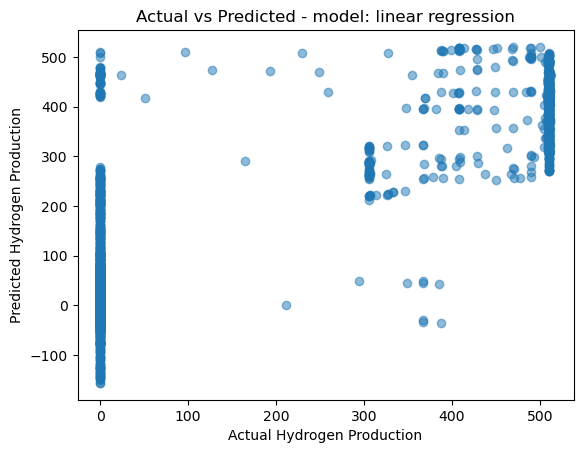

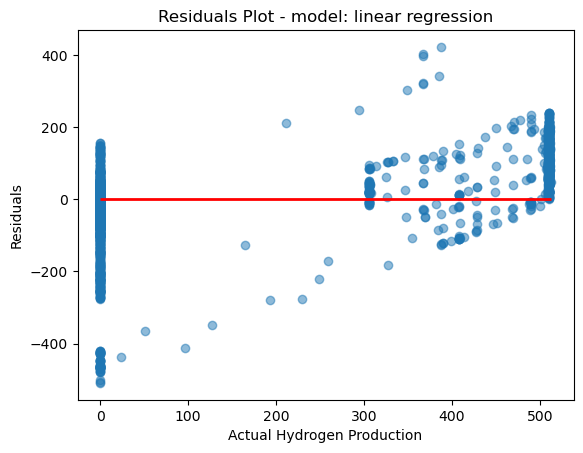

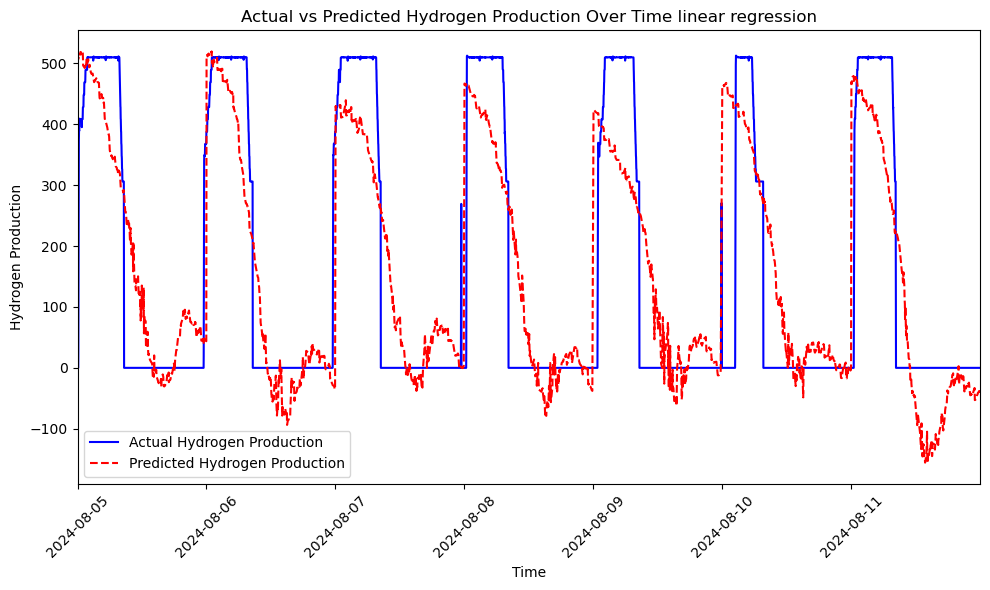



Evaluating model: Ridge Regression (alpha=0.1)
Mean Absolute Error (MAE): 88.14
Mean Squared Error (MSE): 16104.92
R² Score: 0.69
Explained Variance Score: 0.69


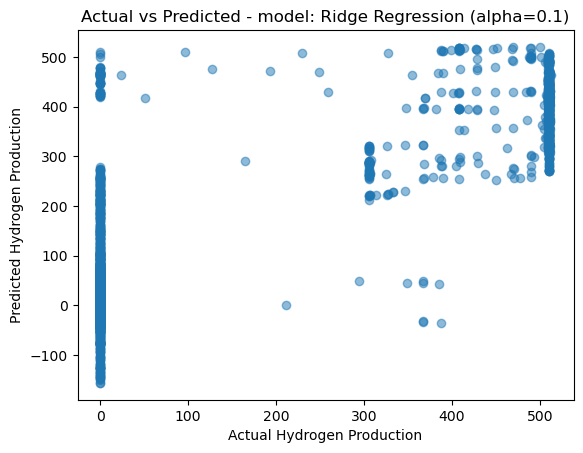

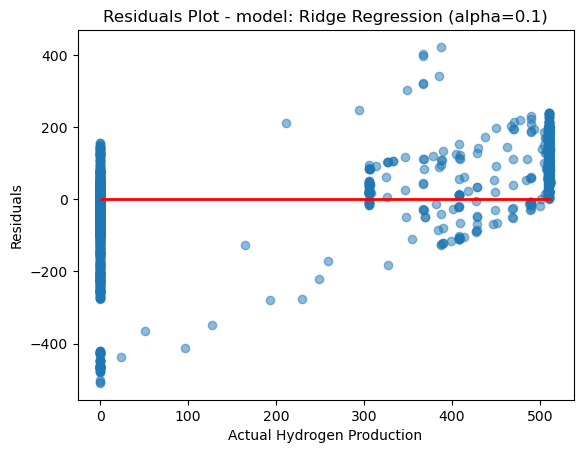

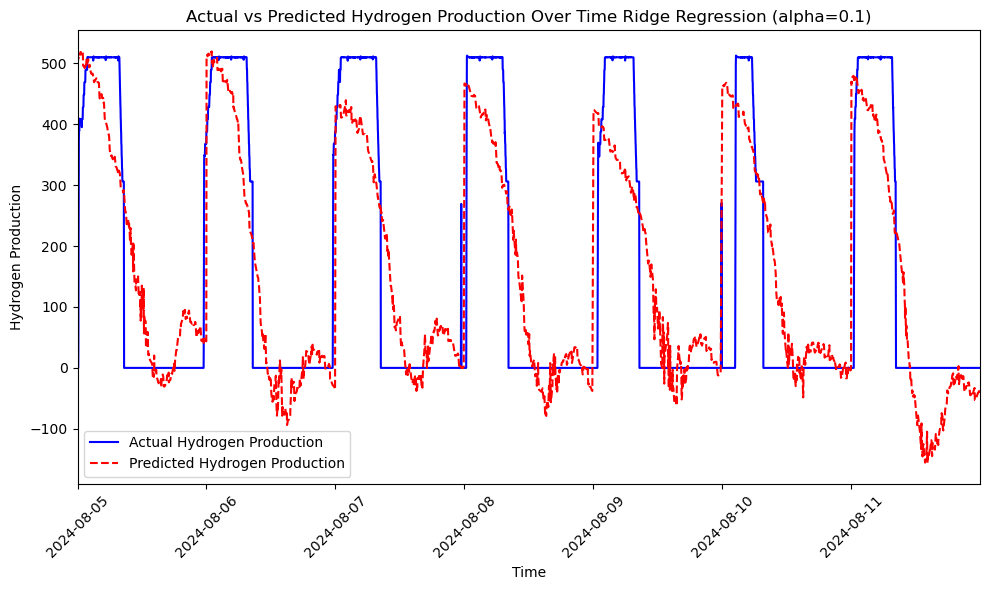



Evaluating model: Ridge Regression (alpha=1)
Mean Absolute Error (MAE): 88.14
Mean Squared Error (MSE): 16104.92
R² Score: 0.69
Explained Variance Score: 0.69


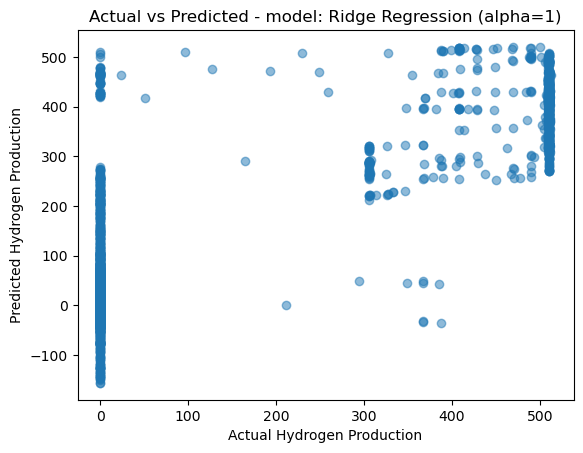

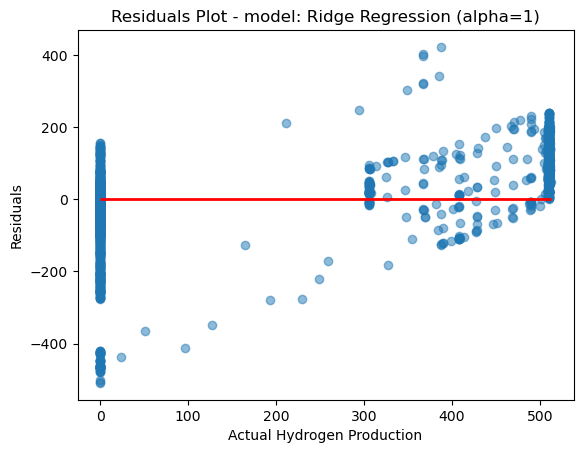

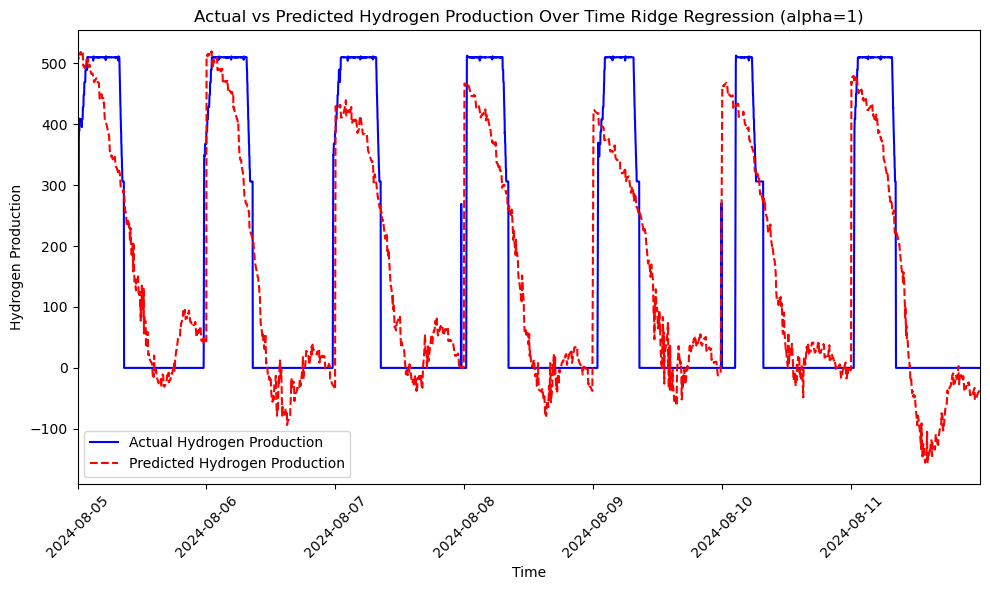



Evaluating model: Lasso Regression (alpha=0.1)
Mean Absolute Error (MAE): 88.15
Mean Squared Error (MSE): 16105.41
R² Score: 0.69
Explained Variance Score: 0.69


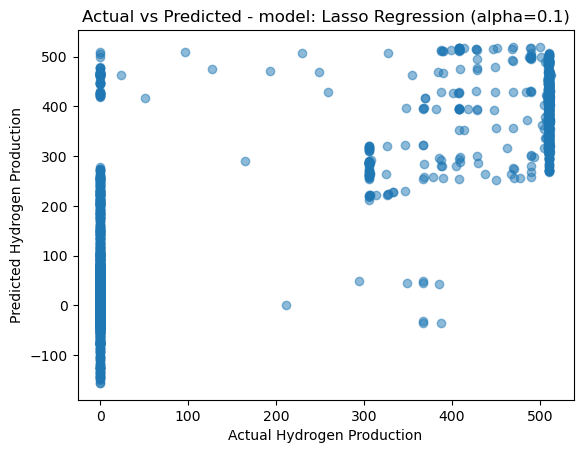

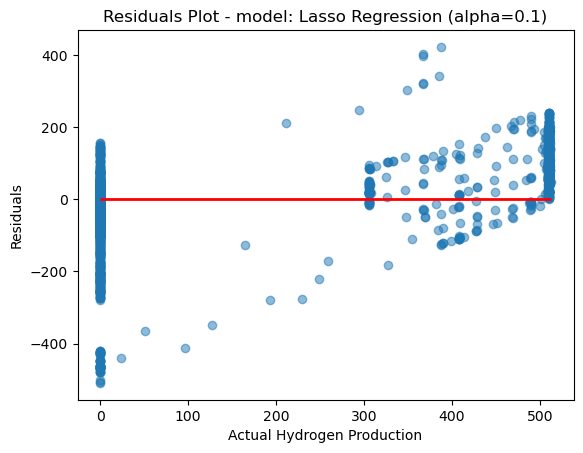

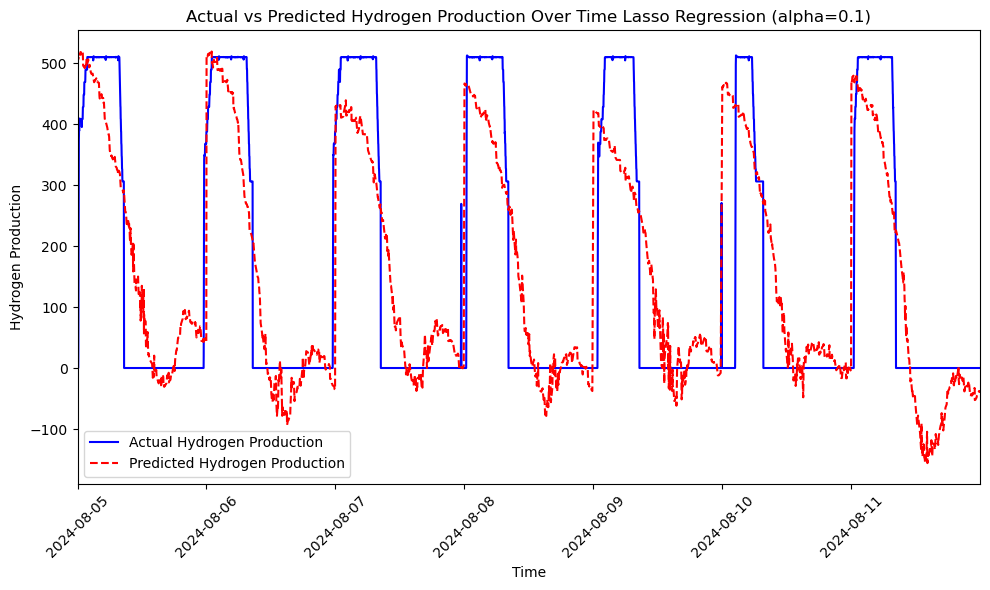



Evaluating model: Lasso Regression (alpha=1)
Mean Absolute Error (MAE): 88.27
Mean Squared Error (MSE): 16112.21
R² Score: 0.69
Explained Variance Score: 0.69


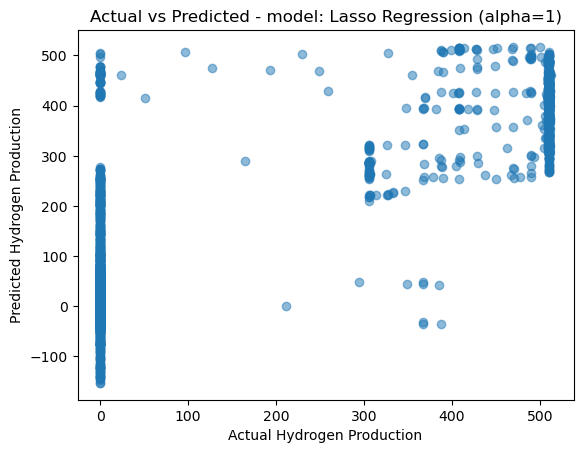

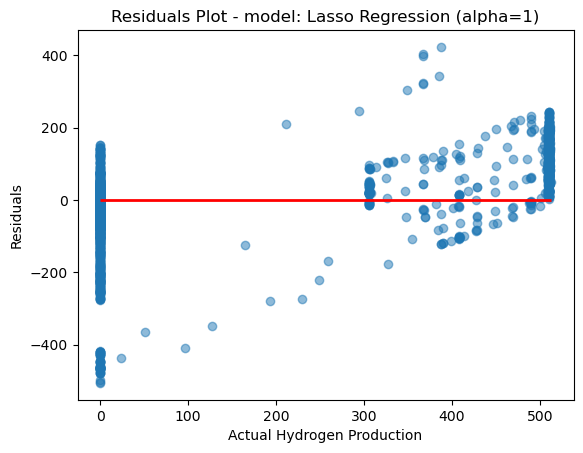

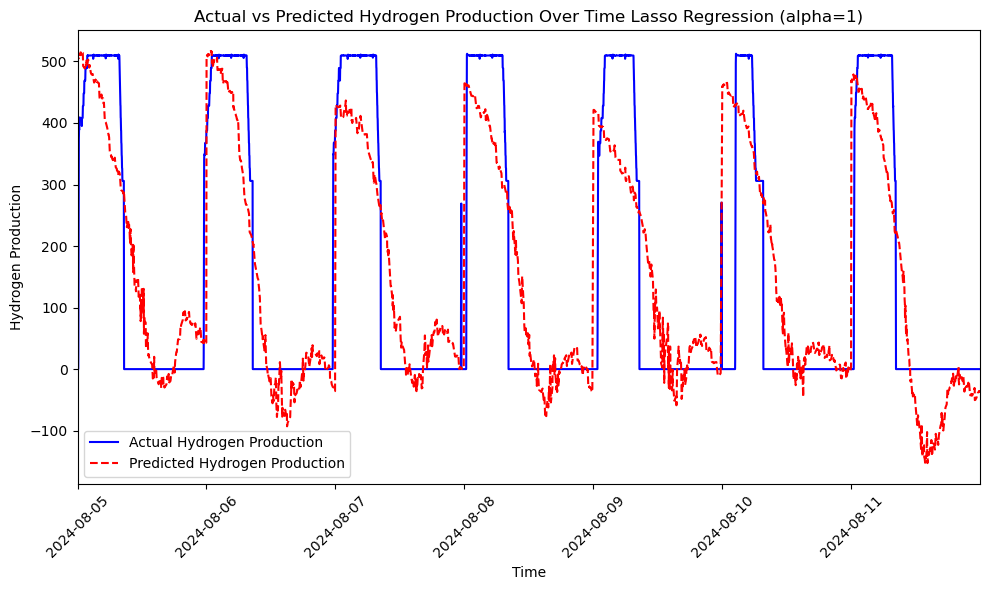

In [92]:
LRModel = LinearRegression()
Regression_Classifier(LRModel,X_train_scaled,y_train,X_test_scaled,y_test, "linear regression")


# Ridge Regression (L2 regularization)
alpha_values = [0.1, 1]
for alpha in alpha_values:
    ridge_model = Ridge(alpha=alpha)
    Regression_Classifier(ridge_model, X_train_scaled, y_train, X_test_scaled, y_test, f"Ridge Regression (alpha={alpha})")

# Lasso Regression (L1 regularization)
for alpha in alpha_values:
    lasso_model = Lasso(alpha=alpha)
    Regression_Classifier(lasso_model, X_train_scaled, y_train, X_test_scaled, y_test, f"Lasso Regression (alpha={alpha})")

We have now seen that linear regression does not work well for this model. We have also seen that it does work well when ALL data is present (likely because the target variable is (roughly) in that dataset. We test for different models:

Evaluating model: XGBoost (learning_rate=0.01)
Mean Absolute Error (MAE): 84.21
Mean Squared Error (MSE): 8924.60
R² Score: 0.83
Explained Variance Score: 0.83


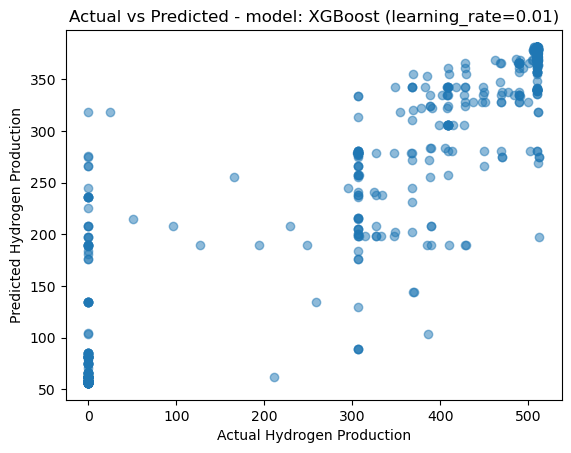

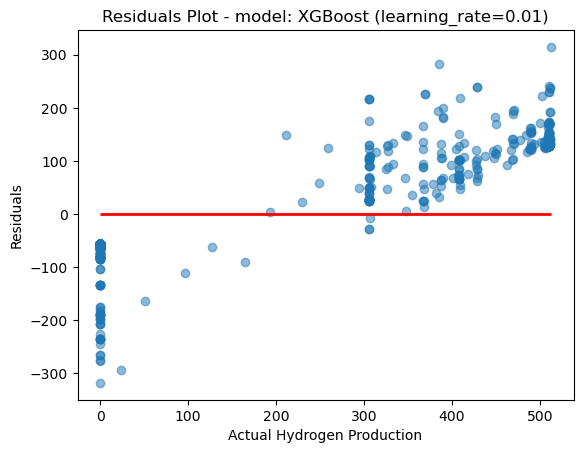

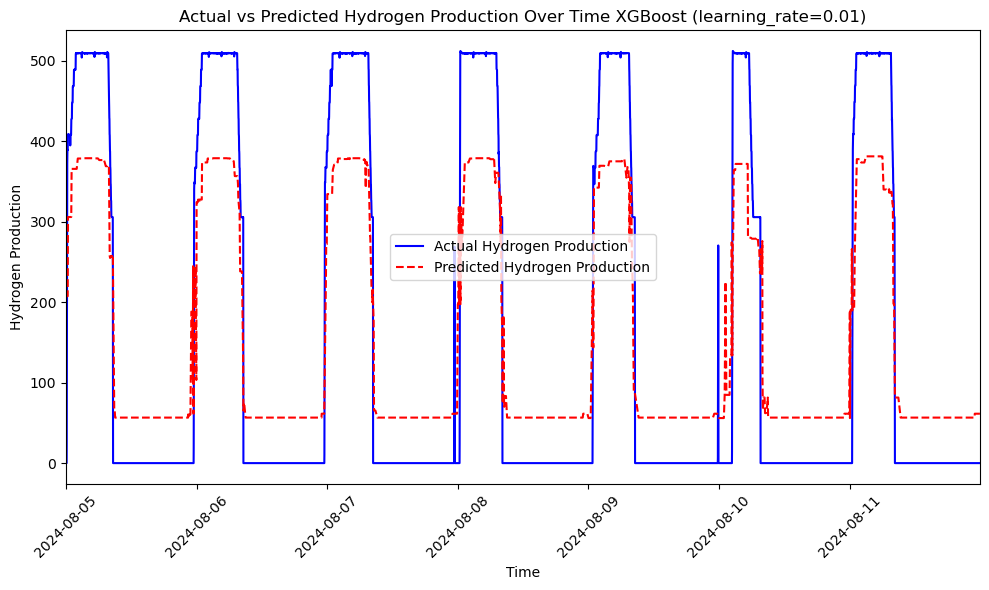



Evaluating model: XGBoost (learning_rate=0.1)
Mean Absolute Error (MAE): 10.14
Mean Squared Error (MSE): 1449.90
R² Score: 0.97
Explained Variance Score: 0.97


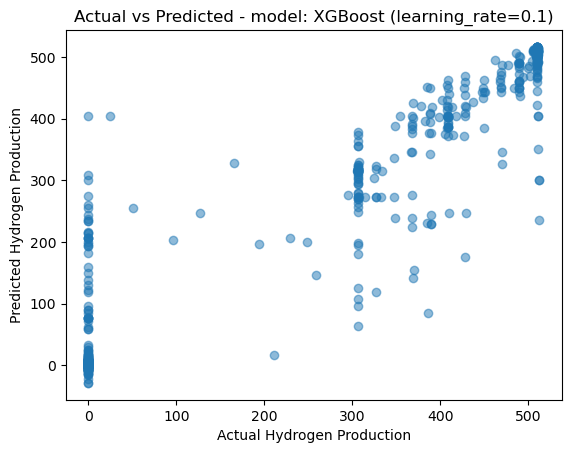

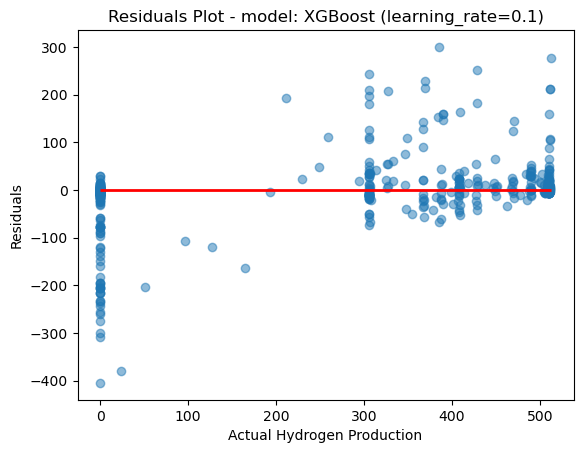

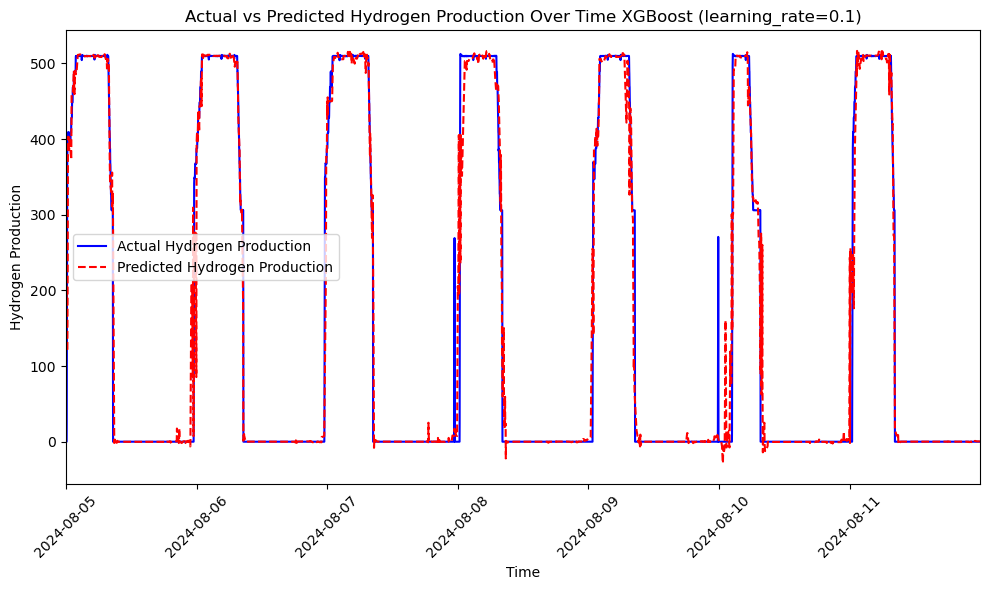



Evaluating model: XGBoost (learning_rate=0.2)
Mean Absolute Error (MAE): 9.23
Mean Squared Error (MSE): 1419.71
R² Score: 0.97
Explained Variance Score: 0.97


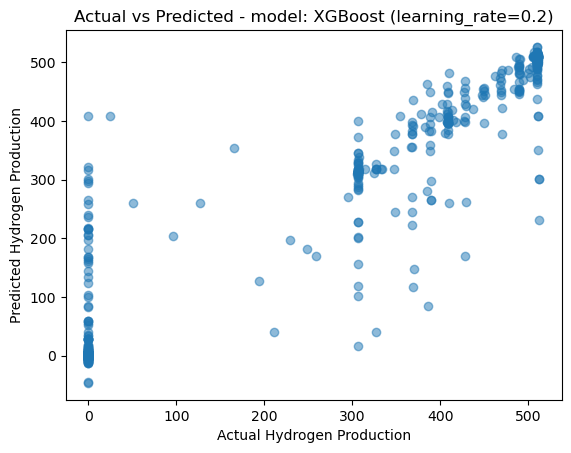

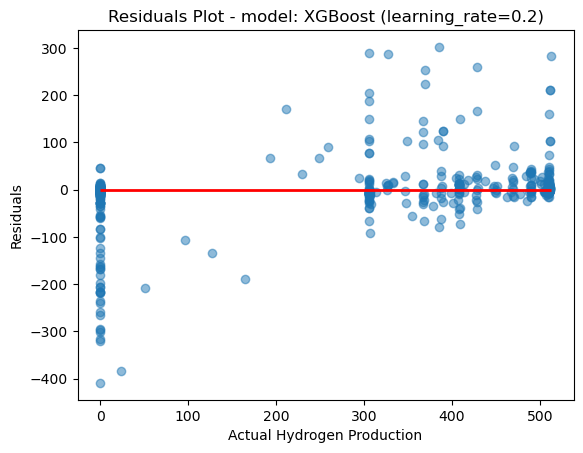

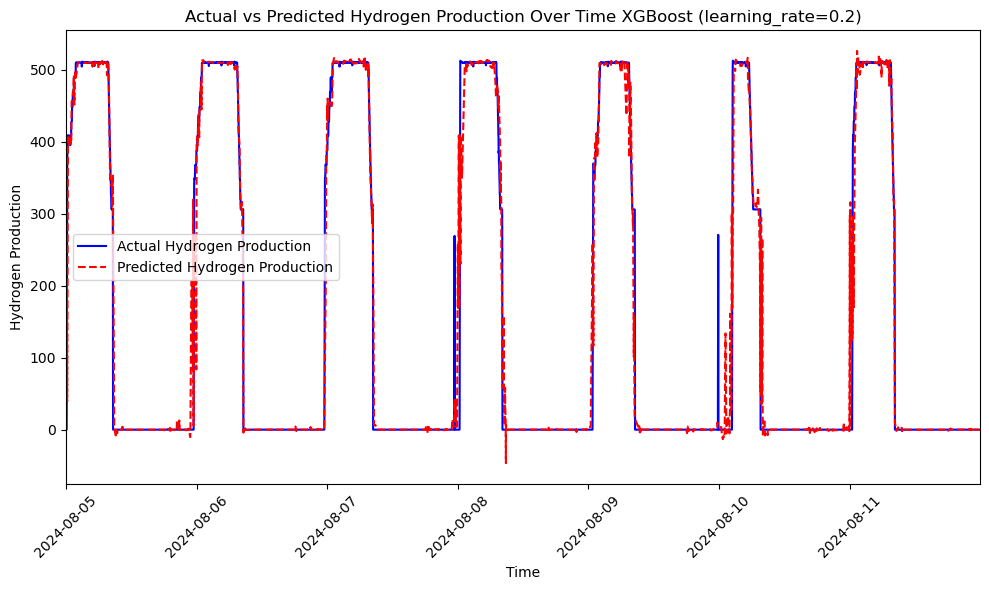



Evaluating model: Random Forest (n_estimators=50)
Mean Absolute Error (MAE): 8.25
Mean Squared Error (MSE): 1620.75
R² Score: 0.97
Explained Variance Score: 0.97


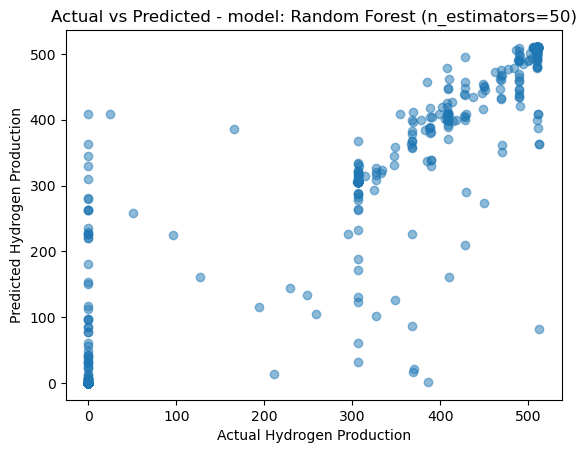

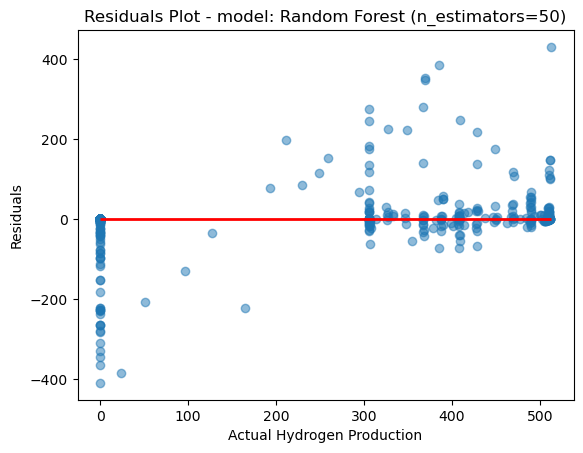

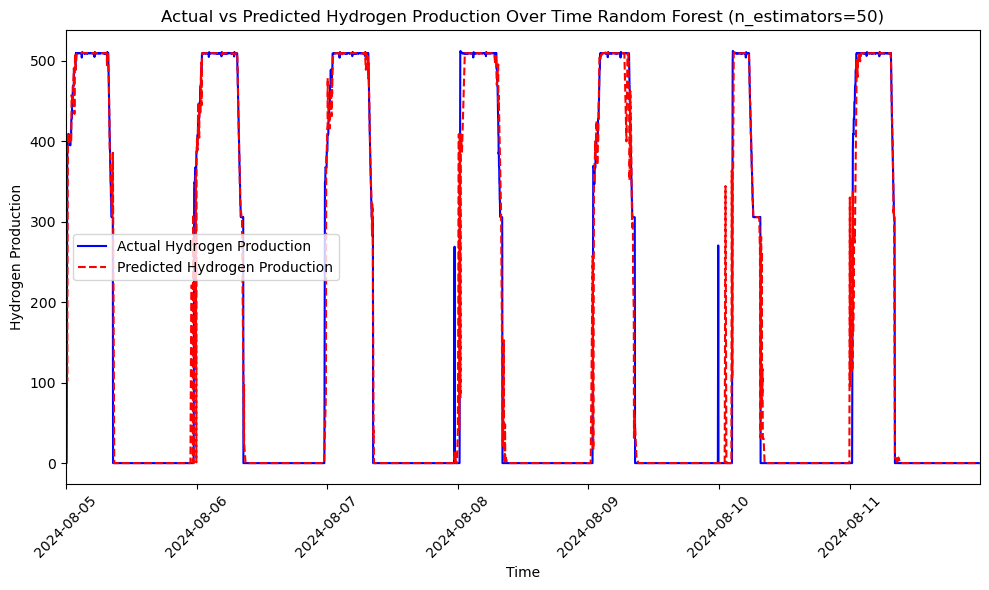



Evaluating model: Random Forest (n_estimators=100)
Mean Absolute Error (MAE): 8.17
Mean Squared Error (MSE): 1625.61
R² Score: 0.97
Explained Variance Score: 0.97


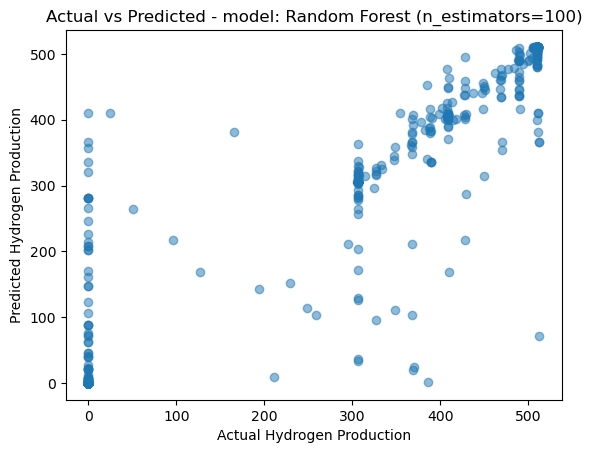

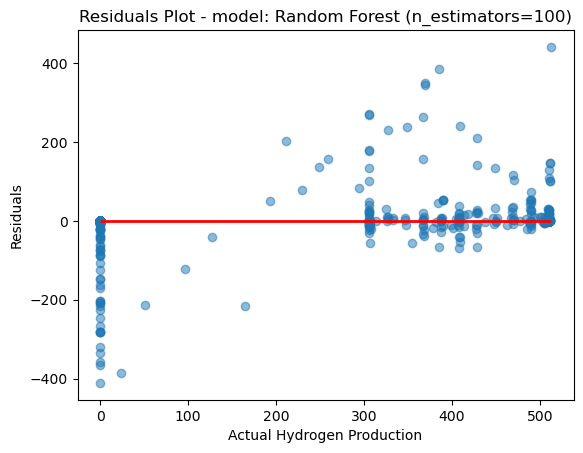

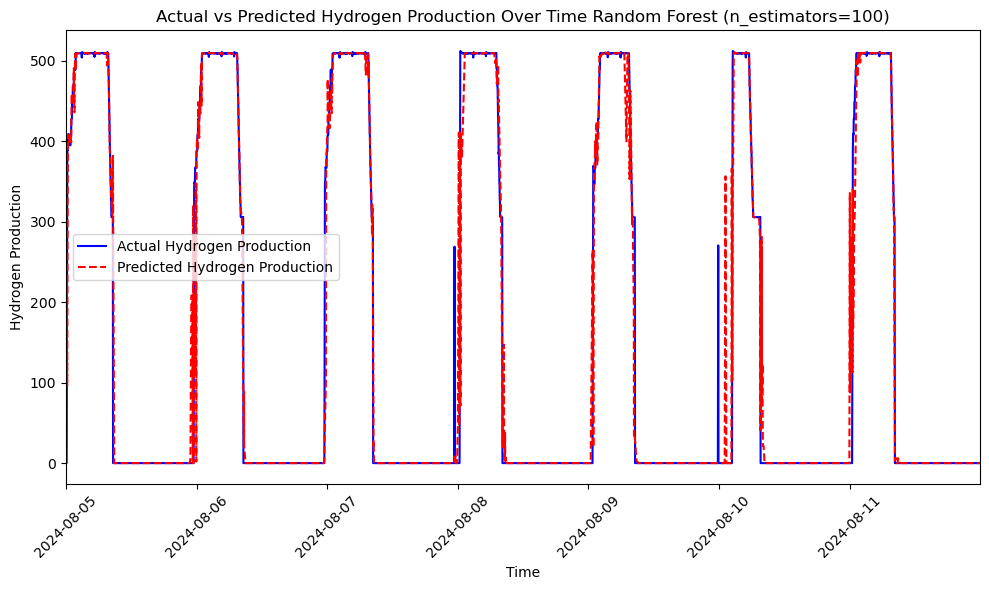



Evaluating model: Random Forest (n_estimators=200)
Mean Absolute Error (MAE): 8.15
Mean Squared Error (MSE): 1624.55
R² Score: 0.97
Explained Variance Score: 0.97


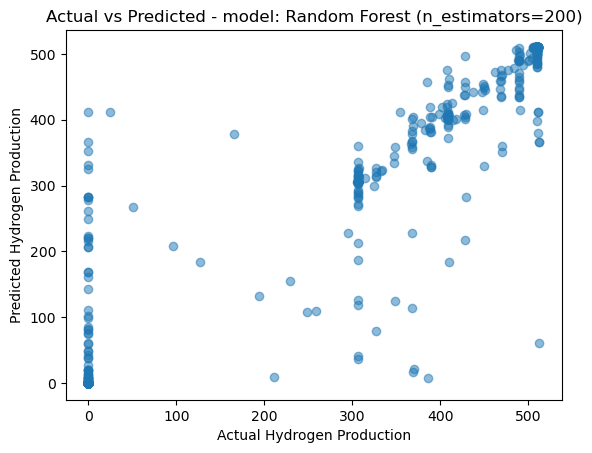

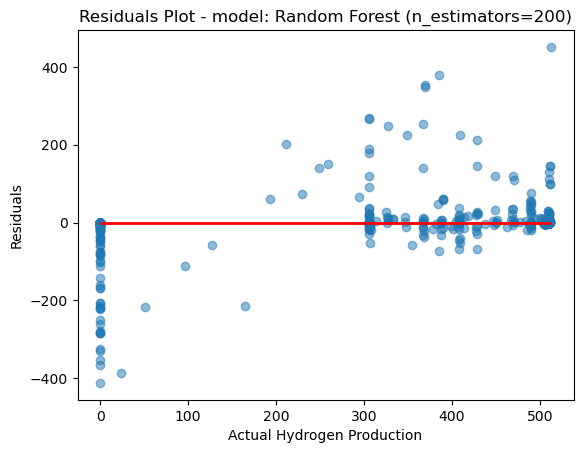

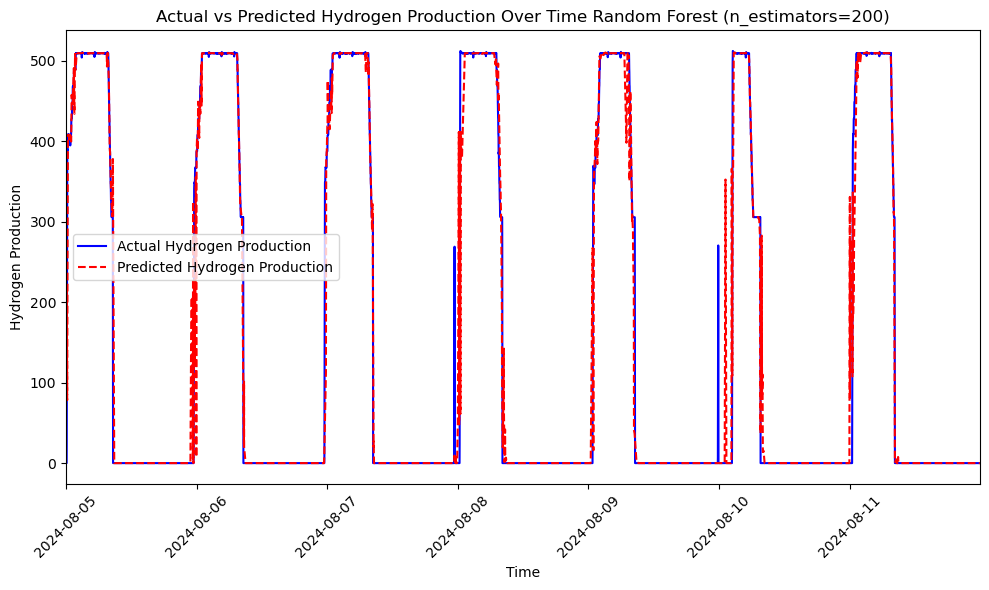



Evaluating model: KNN (n_neighbors=3)
Mean Absolute Error (MAE): 7.92
Mean Squared Error (MSE): 1520.28
R² Score: 0.97
Explained Variance Score: 0.97


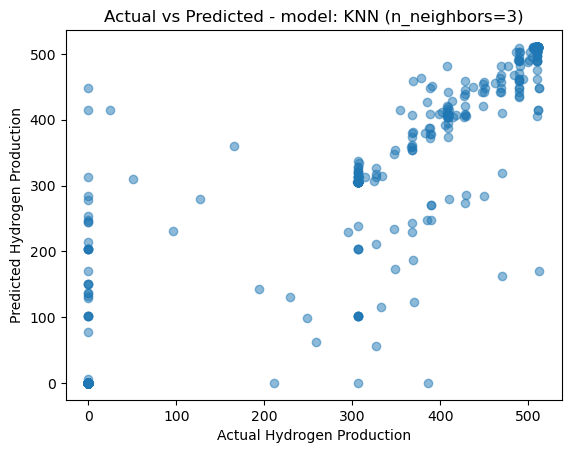

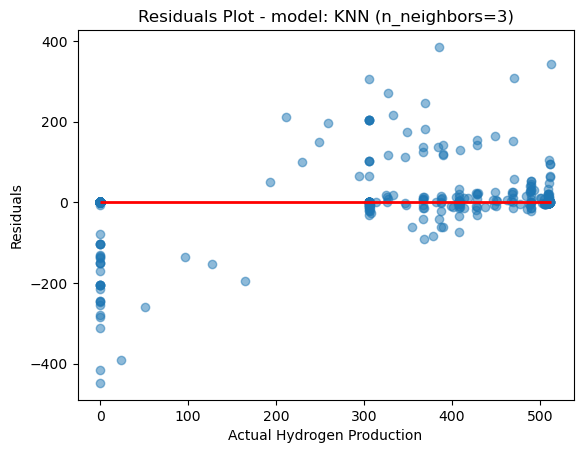

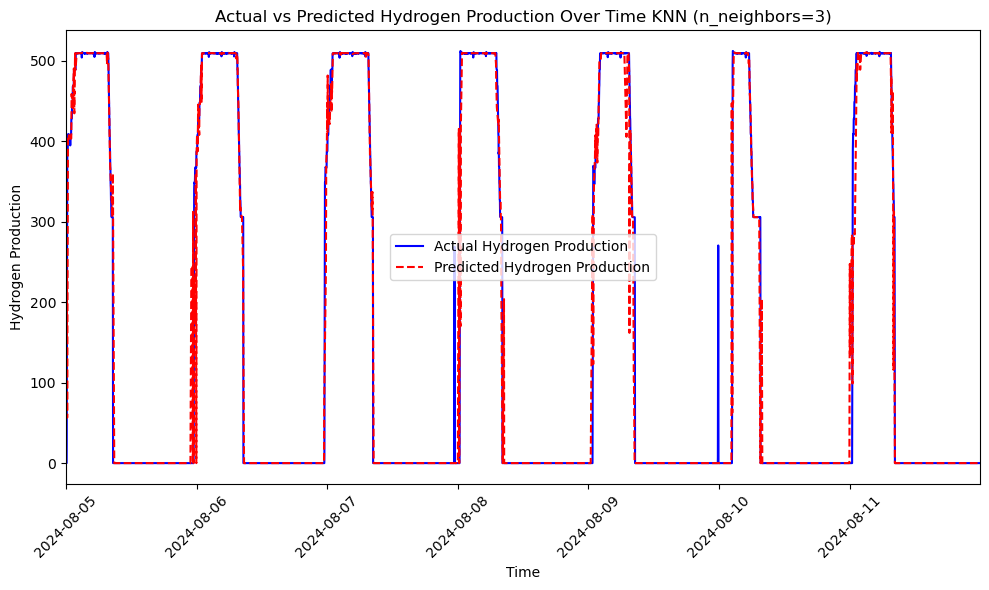



Evaluating model: KNN (n_neighbors=5)
Mean Absolute Error (MAE): 8.46
Mean Squared Error (MSE): 1529.55
R² Score: 0.97
Explained Variance Score: 0.97


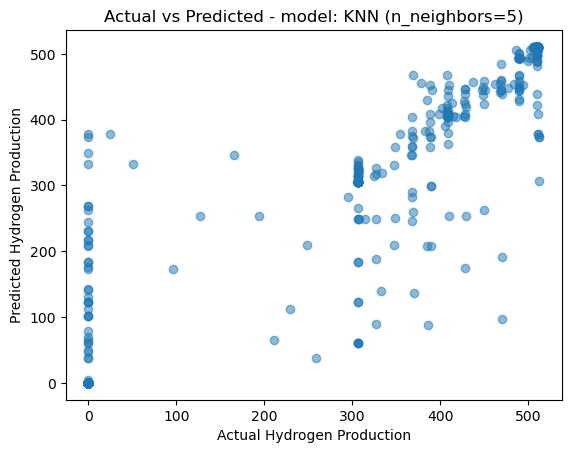

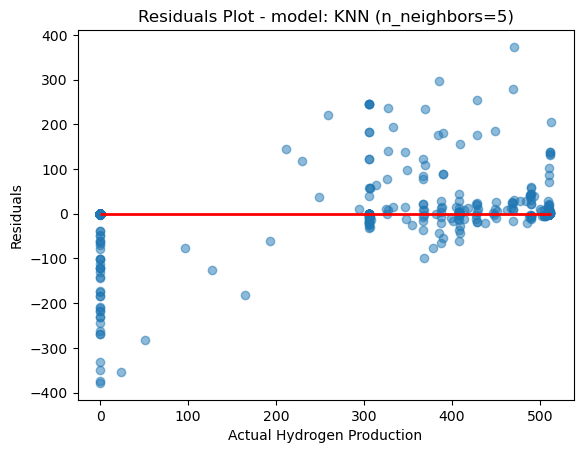

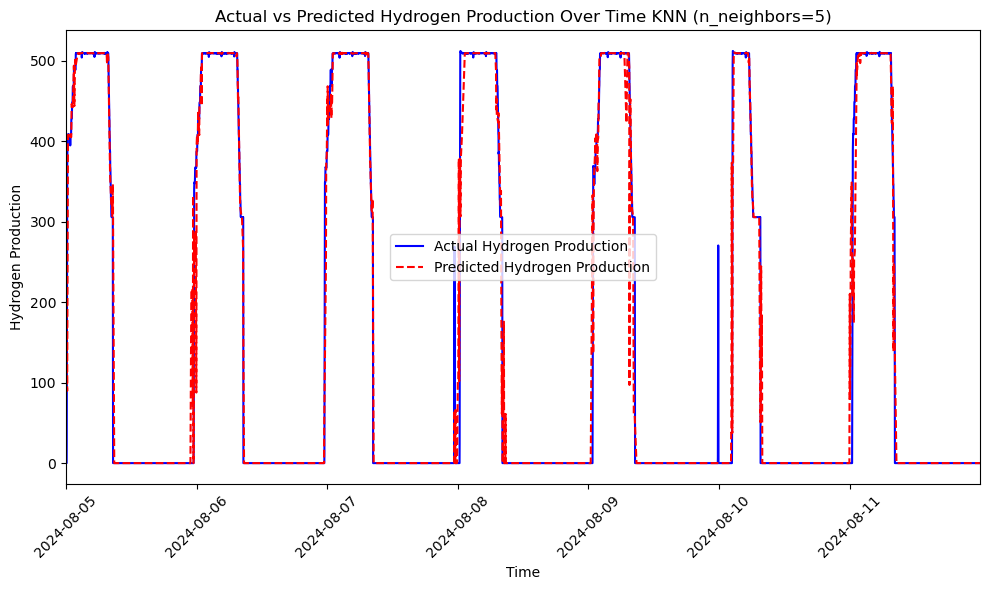



Evaluating model: KNN (n_neighbors=7)
Mean Absolute Error (MAE): 8.64
Mean Squared Error (MSE): 1512.44
R² Score: 0.97
Explained Variance Score: 0.97


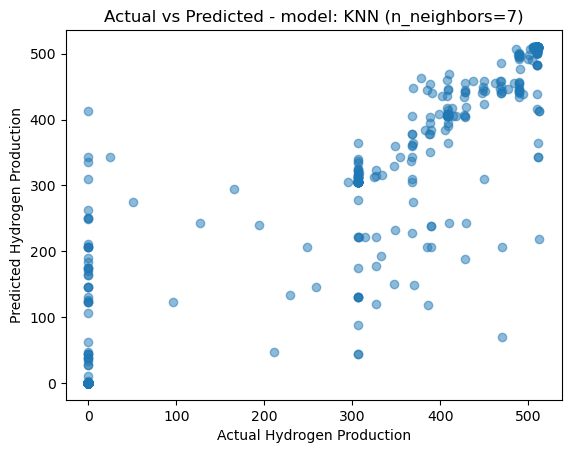

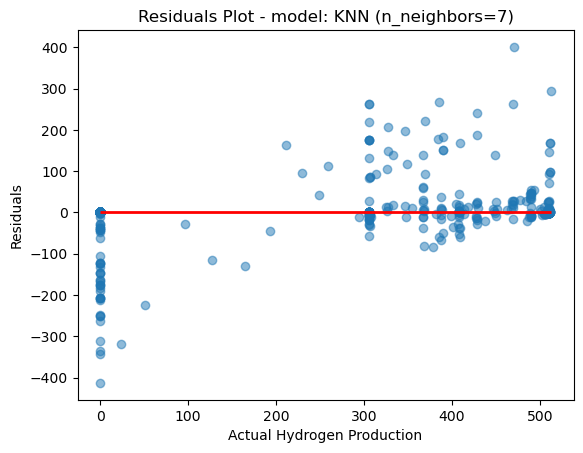

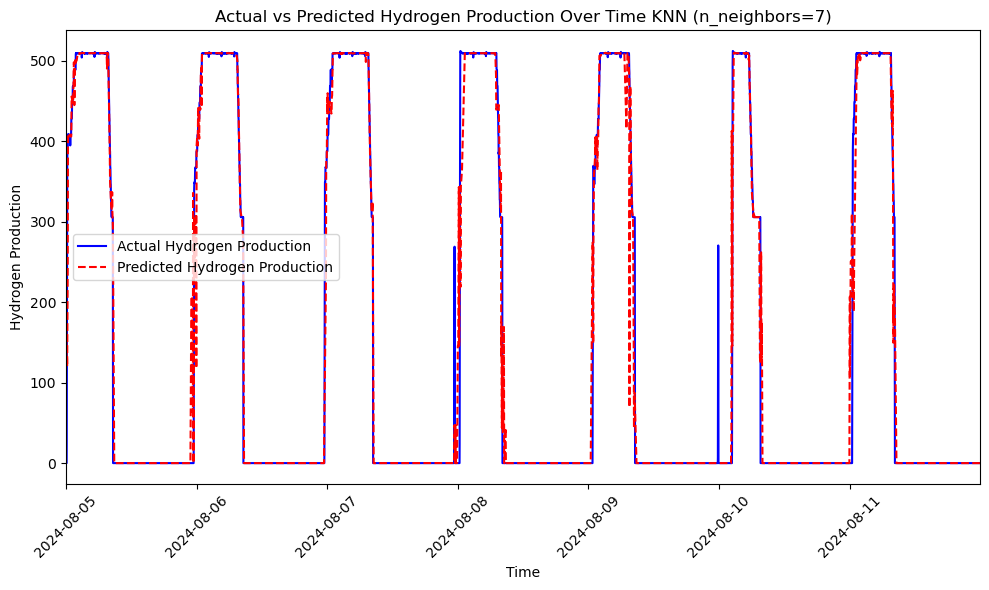



Evaluating model: KNN (n_neighbors=9)
Mean Absolute Error (MAE): 8.90
Mean Squared Error (MSE): 1524.48
R² Score: 0.97
Explained Variance Score: 0.97


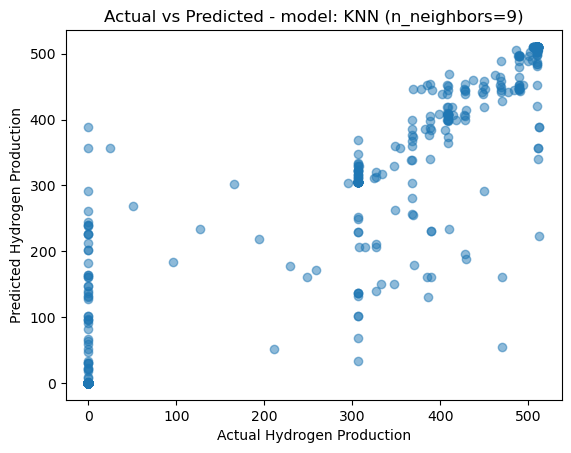

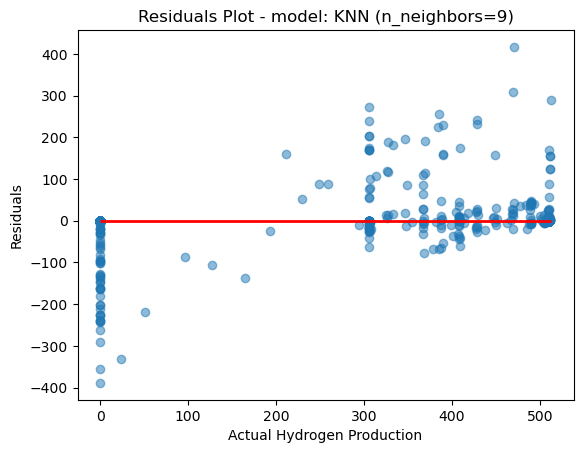

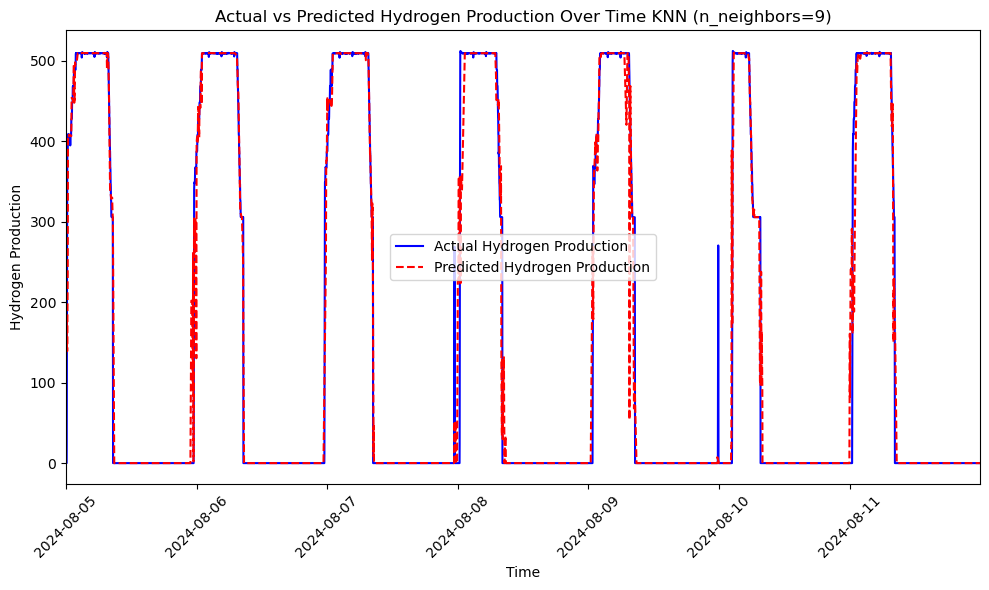



Evaluating model: SVM (kernel=linear)
Mean Absolute Error (MAE): 83.58
Mean Squared Error (MSE): 17534.75
R² Score: 0.67
Explained Variance Score: 0.68


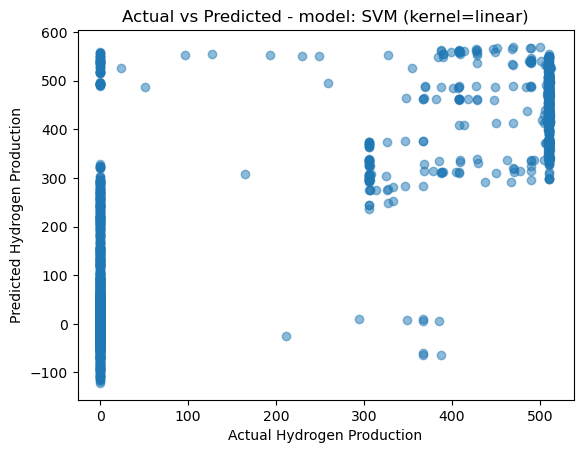

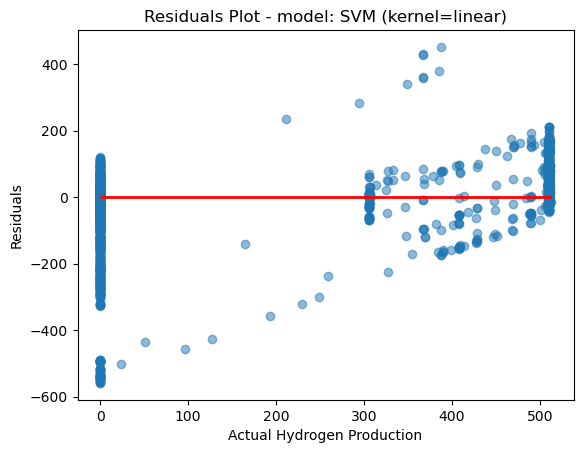

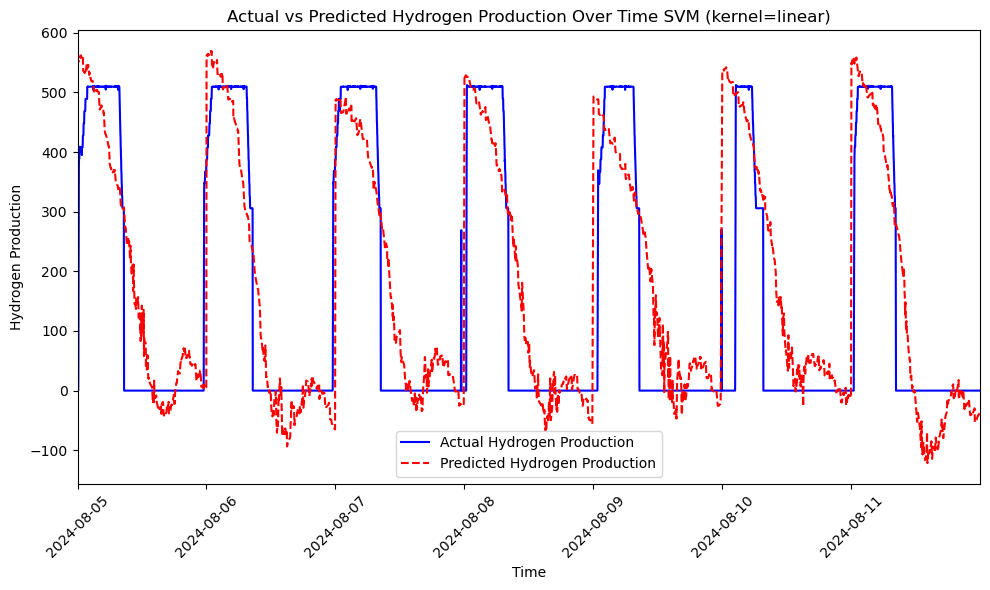



Evaluating model: SVM (kernel=poly)
Mean Absolute Error (MAE): 119.58
Mean Squared Error (MSE): 28994.13
R² Score: 0.45
Explained Variance Score: 0.50


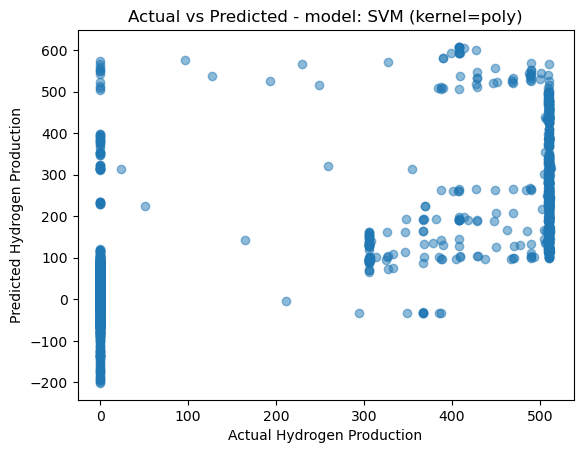

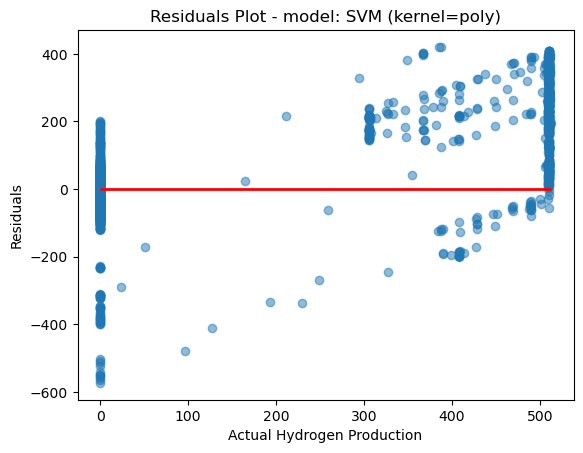

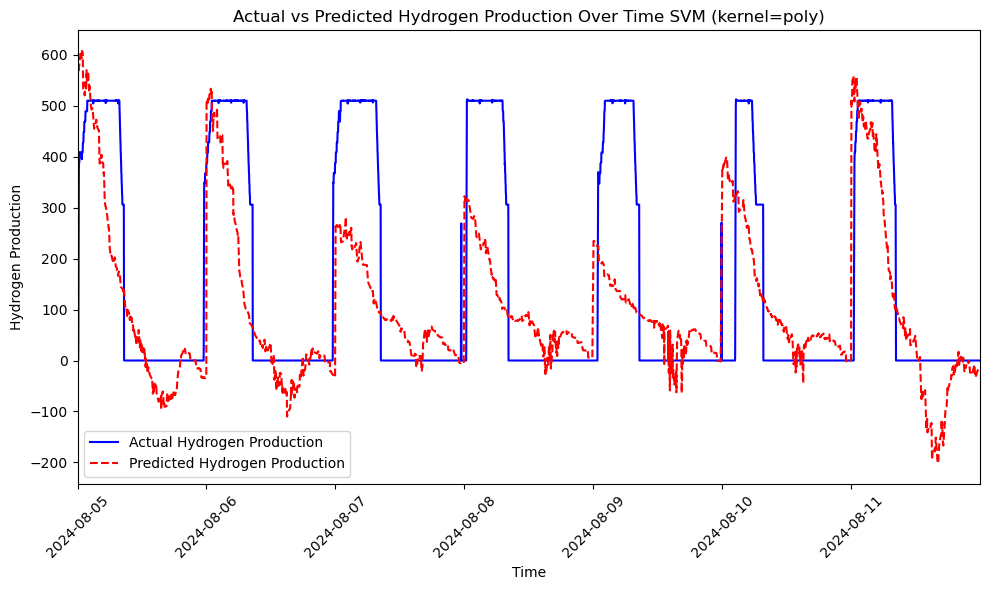



Evaluating model: SVM (kernel=rbf)
Mean Absolute Error (MAE): 53.80
Mean Squared Error (MSE): 11419.30
R² Score: 0.78
Explained Variance Score: 0.78


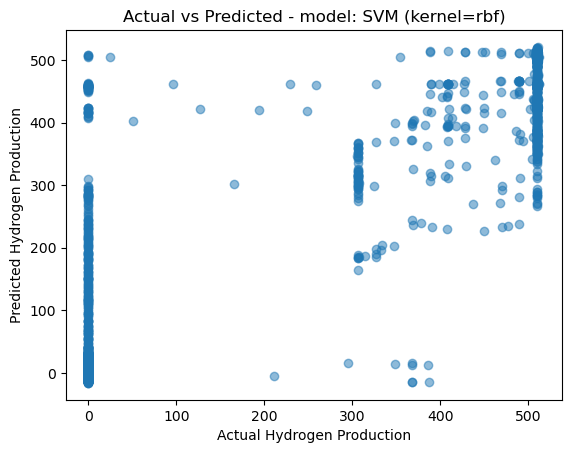

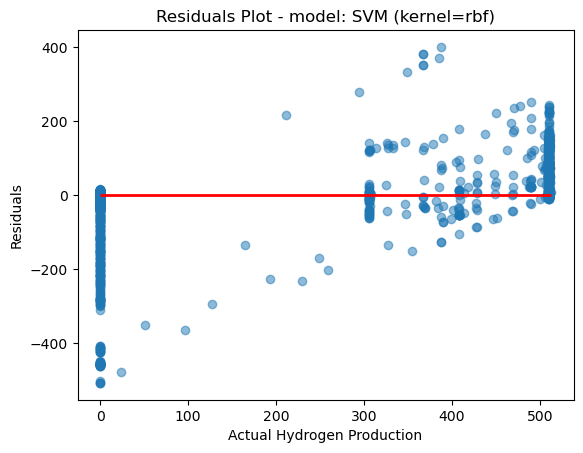

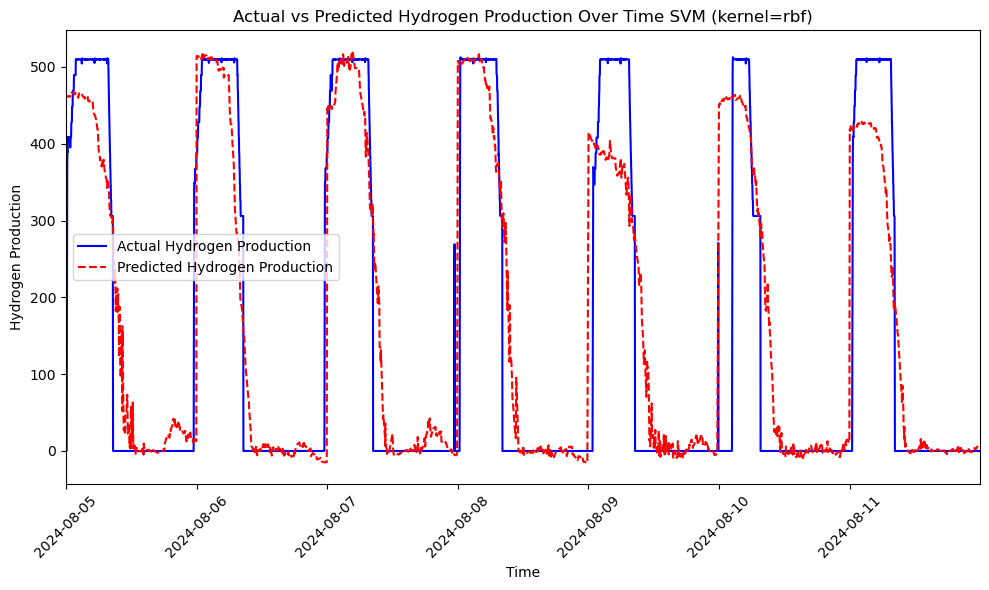



Evaluating model: Decision Tree (max_depth=5)
Mean Absolute Error (MAE): 15.82
Mean Squared Error (MSE): 2831.12
R² Score: 0.95
Explained Variance Score: 0.95


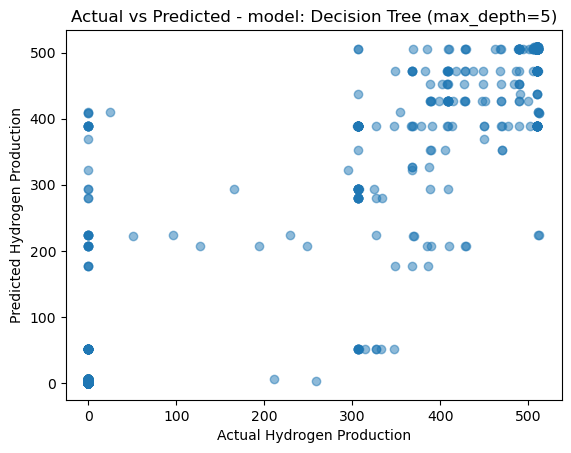

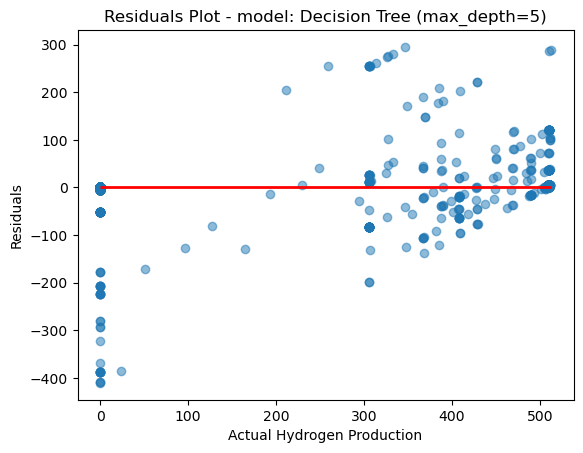

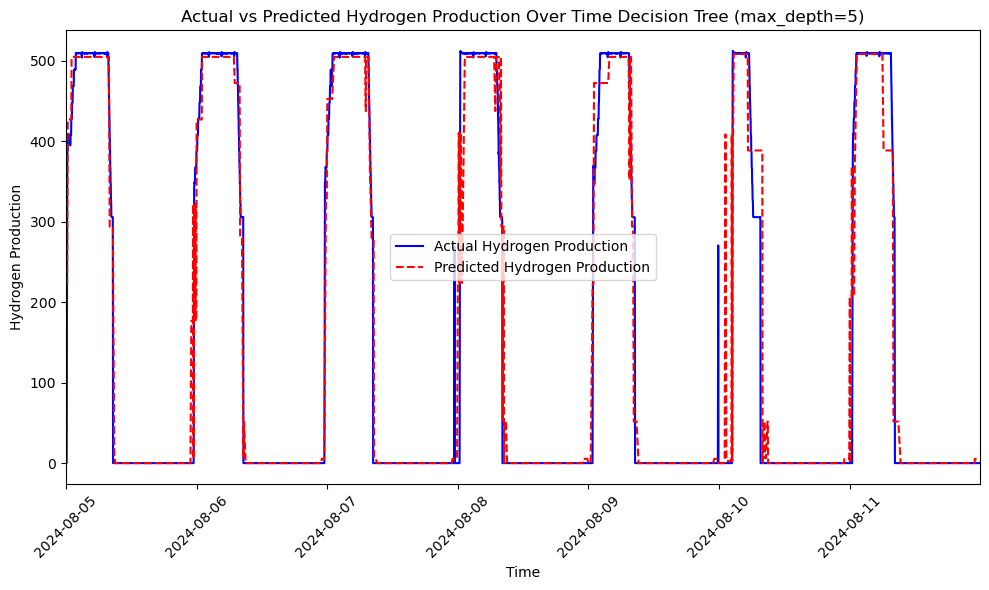



Evaluating model: Decision Tree (max_depth=10)
Mean Absolute Error (MAE): 7.87
Mean Squared Error (MSE): 1906.05
R² Score: 0.96
Explained Variance Score: 0.96


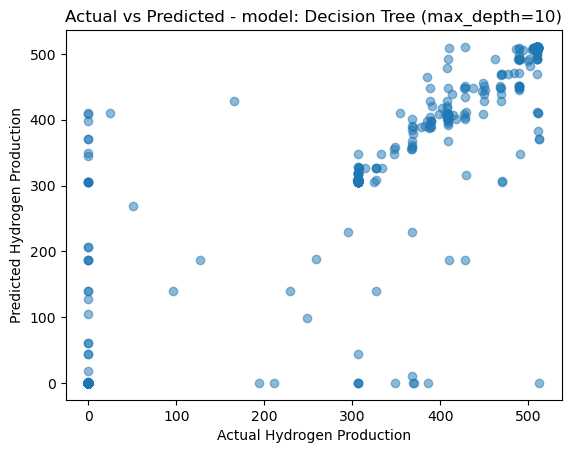

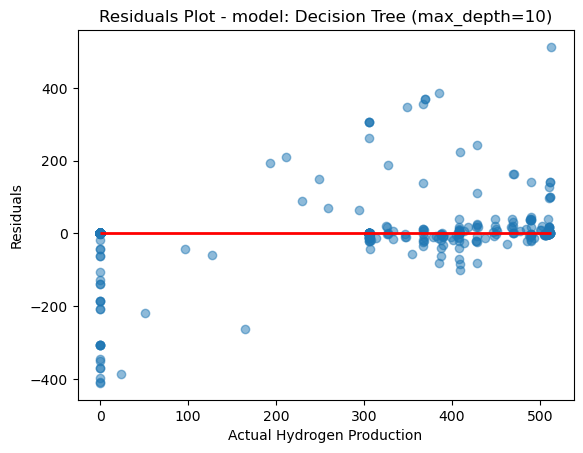

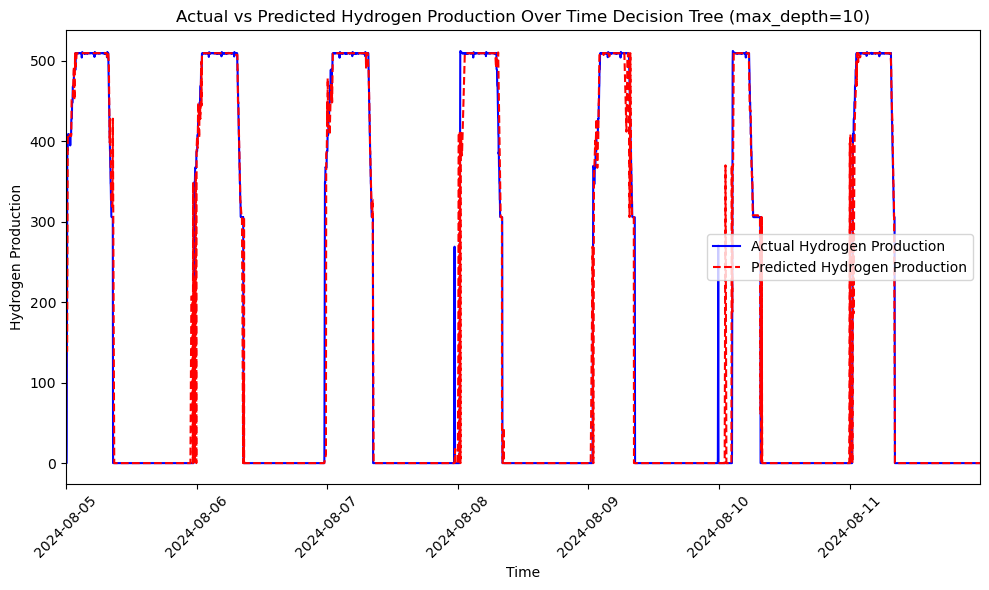



Evaluating model: Decision Tree (max_depth=20)
Mean Absolute Error (MAE): 7.95
Mean Squared Error (MSE): 1989.67
R² Score: 0.96
Explained Variance Score: 0.96


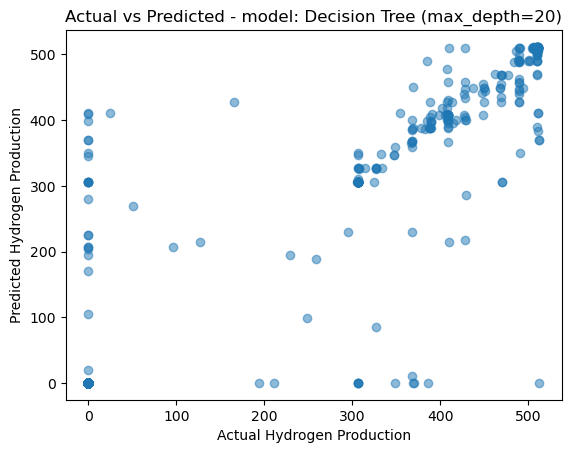

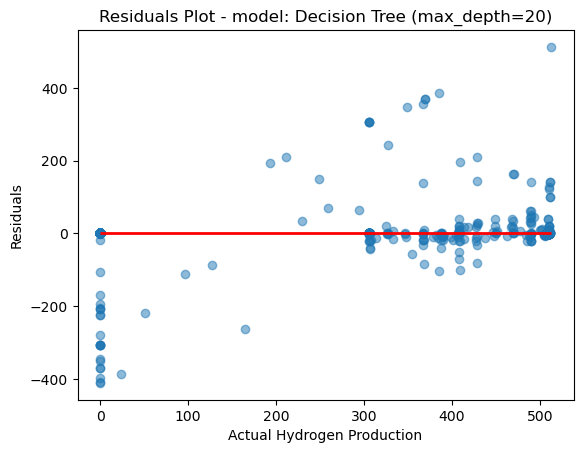

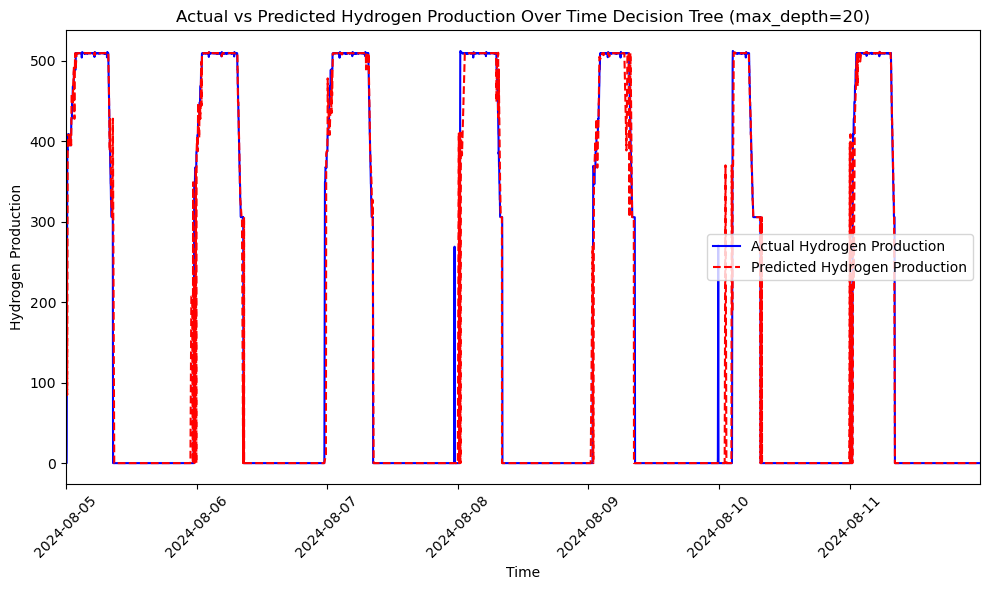

In [94]:
# XGBoost Regressor with different learning rates and max_depth
learning_rates = [0.01, 0.1, 0.2]
for rate in learning_rates:
    xgb_model = XGBRegressor(learning_rate=rate, n_estimators=100, max_depth=5, random_state=42)
    Regression_Classifier(xgb_model, X_train_scaled, y_train, X_test_scaled, y_test, f"XGBoost (learning_rate={rate})")

# Random Forest Regressor with different numbers of trees
for n_estimators in [50, 100, 200]:
    rf_model = RandomForestRegressor(n_estimators=n_estimators, random_state=42)
    Regression_Classifier(rf_model, X_train_scaled, y_train, X_test_scaled, y_test, f"Random Forest (n_estimators={n_estimators})")

# KNN: Regressor
for n in [3, 5, 7, 9]:
    knn_model = KNeighborsRegressor(n_neighbors=n)
    Regression_Classifier(knn_model, X_train_scaled, y_train, X_test_scaled, y_test, f"KNN (n_neighbors={n})")

# SVM Regressor with different kernels
kernels = ['linear', 'poly', 'rbf']
for kernel in kernels:
    svr_model = SVR(kernel=kernel, C=1.0, epsilon=0.1)
    Regression_Classifier(svr_model, X_train_scaled, y_train, X_test_scaled, y_test, f"SVM (kernel={kernel})")

# Decision Tree Regressor with different max_depth values (10 was best so we add higher values now)
for depth in [5, 10, 20]:
    dt_model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    Regression_Classifier(dt_model, X_train_scaled, y_train, X_test_scaled, y_test, f"Decision Tree (max_depth={depth})")

### Further model evaluation

Both the actual production and predicted production are integrated over time to determine accuracy.

In [35]:
def integrate_h2(*var, name):
    plt.figure()
    if isinstance(var[0], str):
        data = globals()[var[0]]
        time = data['time']
        values = data['value_float']
        time_numeric = (time - time.iloc[0]).dt.total_seconds().astype(int)
        positive_values = np.where(values > 0, values, 0)
        H2pos = np.trapz(values, time_numeric) # Perform integration
        plt.title('Actual hydrogen production over time')
    else:
        time = time_test_sorted
        values = y_pred_sorted
        time_numeric = (time - time.iloc[0]).dt.total_seconds().astype(int)
        positive_values = np.where(values > 0, values, 0)
        H2pos = np.trapz(values, time_numeric) # Perform integration
        plt.title('Predicted hydrogen production over time')

    
    H2Prod = H2Density*H2pos/(3600*1000) # H2 flow to kg
    EnergyH2 = LHV_H2*H2Prod/(3600*1000) # H2 flow to kWh(chem) (of H2)
    plt.plot(time, values, label='Hydrogen production')
    plt.fill_between(time, positive_values, alpha=0.2, label=f'Hydrogen produced: {H2Prod:.3f} kg', color='blue')
    plt.fill_between(time, positive_values, alpha=0.2, label=f'Energy content: {EnergyH2:.3f} kWh', color='blue')

    plt.xlabel('Time')
    plt.ylabel('Hydrogen Flow [NL/h]')
    plt.xlim(min(time),max(time))
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join("figures/regression", f"H2 integrated - {name}.png"), dpi=300, bbox_inches='tight')

    plt.show()
    return H2Prod

Evaluating model: KNN - n=3
Mean Absolute Error (MAE): 7.92
Mean Squared Error (MSE): 1520.28
R² Score: 0.97
Explained Variance Score: 0.97


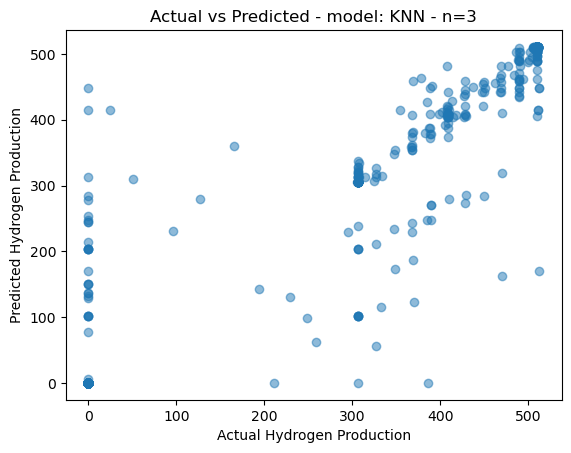

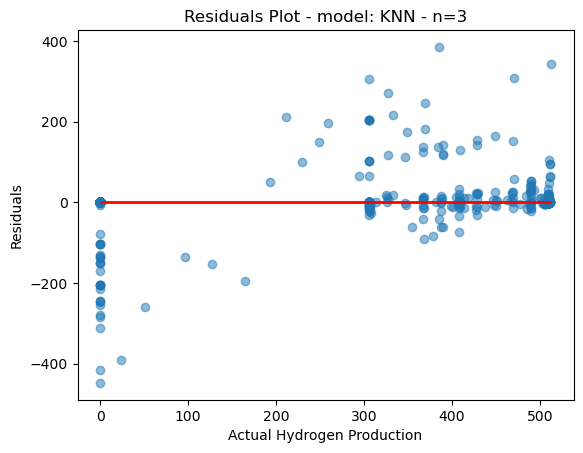

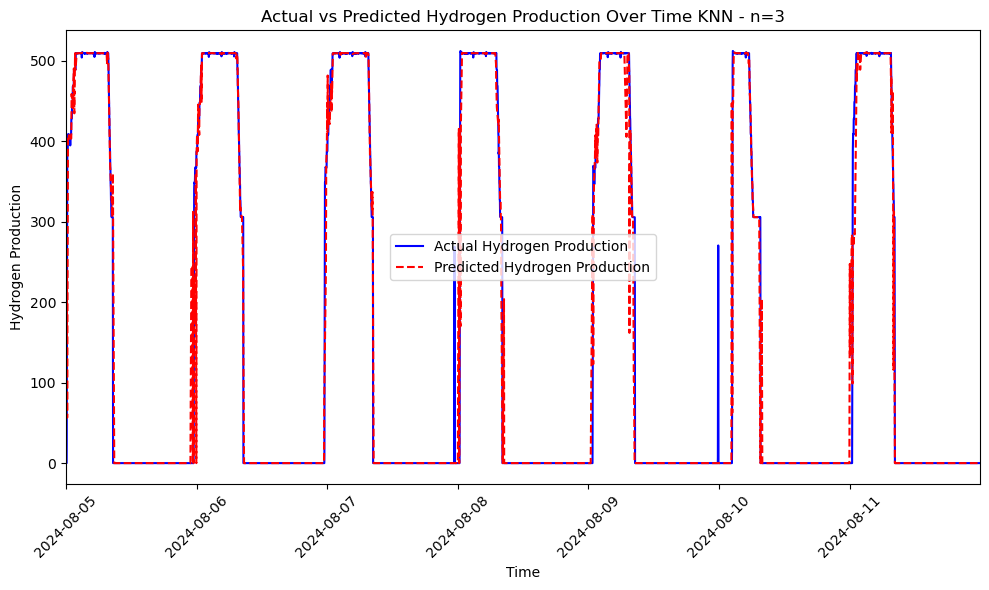

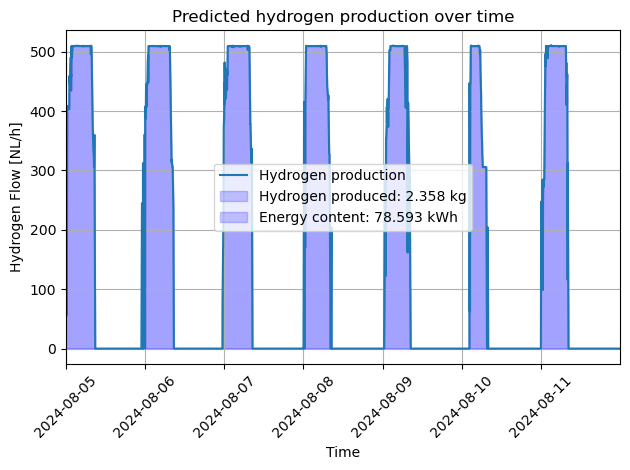

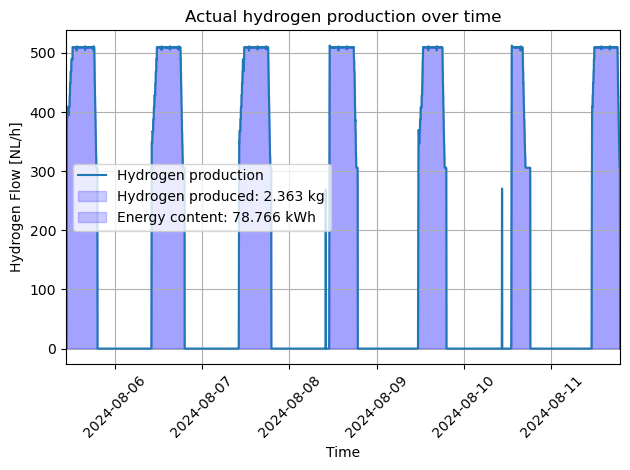

Underestimation: 0.005 kg H2
Percentage error: -0.220%


In [96]:
# Lets evaluate the best performing model and integrate over time to determine difference:
# Best model so far:  DT regressor with depth = 10
globals()['Electrolyser_Hydrogen_Flow'] = pd.read_pickle(os.path.join(subfolder, "Electrolyser_Hydrogen_Flow_Rate.pkl"))


model = KNeighborsRegressor(n_neighbors=3)

time_test_sorted, y_pred_sorted = Regression_Classifier(model, X_train_scaled, y_train, X_test_scaled, y_test, f"KNN - n=3")

H2Prod_pred = integrate_h2(time_test_sorted, y_pred_sorted, name = "predicted")

H2Prod_act = integrate_h2('Electrolyser_Hydrogen_Flow', name = "actual")
estimation_diff = H2Prod_pred - H2Prod_act

# Calculate the percentage error
if H2Prod_act != 0:
    percentage_error = (estimation_diff / H2Prod_act) * 100
else:
    percentage_error = 0  # If actual production is 0, avoid division by 0

# Print the results
if estimation_diff > 0:
    print(f"Overestimation: {estimation_diff:.3f} kg H2")
elif estimation_diff < 0:
    print(f"Underestimation: {abs(estimation_diff):.3f} kg H2")
else:
    print("No estimation error.")

print(f"Percentage error: {percentage_error:.3f}%")


### Concluding
We conclude that the prediction slightly underestimates the hydrogen production. Though, the promising results do not yet include variability in weather data and may even be overfitted. This should be examined further at a later instance.